# Описание проекта
# Задача
Сеть фитнес-центров «Культурист-датасаентист» разрабатывает стратегию взаимодействия с клиентами на основе аналитических данных. 
Распространённая проблема фитнес-клубов и других сервисов — отток клиентов. Как понять, что клиент больше не с вами? Можно записать в отток тех, кто попросил закрыть договор или удалил аккаунт. Однако клиенты не всегда уходят демонстративно: чаще перестают пользоваться сервисом тихо. <br>
Индикаторы оттока зависят от специфики отрасли. Когда пользователь редко, но стабильно закупается в интернет-магазине — не похоже, что он «отвалился». А вот если две недели не заходит на канал с ежедневно обновляемым контентом, дела плохи: подписчик заскучал и, кажется, оставил вас. <br>
Для фитнес-центра можно считать, что клиент попал в отток, если за последний месяц ни разу не посетил спортзал. Конечно, не исключено, что он уехал на Бали и по приезде обязательно продолжит ходить на фитнес. Однако чаще бывает наоборот. Если клиент начал новую жизнь с понедельника, немного походил в спортзал, а потом пропал — скорее всего, он не вернётся. 
Чтобы бороться с оттоком, отдел по работе с клиентами «Культуриста-датасаентиста» перевёл в электронный вид множество клиентских анкет. 
# Цели: провести анализ и подготовить план действий по удержанию клиентов.  
А именно: 
научиться прогнозировать вероятность оттока (на уровне следующего месяца) для каждого клиента;
сформировать типичные портреты клиентов: выделить несколько наиболее ярких групп и охарактеризовать их основные свойства;
проанализировать основные признаки, наиболее сильно влияющие на отток;
сформулировать основные выводы и разработать рекомендации по повышению качества работы с клиентами:
1) выделить целевые группы клиентов;<br>
2) предложить меры по снижению оттока;<br>
3) определить другие особенности взаимодействия с клиентами.

###  Загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from scipy.cluster.hierarchy import dendrogram, linkage 
from sklearn.cluster import KMeans
import itertools
from plotly import graph_objects as go
# формат показателей с плавающей точкой:
pd.set_option('display.float_format', '{:,.4f}'.format)

# Сброс ограничений на количество выводимых рядов
pd.set_option('display.max_rows', None)

# 
sns.set_theme(rc={'figure.figsize':(10,6)})

In [2]:
# Определим ДФ:
df = pd.read_csv('gym_churn.csv')

### Исследовательский анализ данных (EDA)

In [3]:
#Заведем функцию для первичного осмотра :
def first_look(check):
    long = len(check)
    if long < 10:
        print('Вывод таблицы:')
        display(check)
    else:
        print('Вывод первых 5 строк таблицы:')
        display(check.head(5))
        print('Вывод последних 5 строк таблицы:')
        display(check.tail(5))

    print('\nТипы данных:\n')
    check.info()
    print(f'\nРазмер дф:{check.shape}')
    print('\nСтатистическая сводка (развернём для лучшей читаемости):')
    display(check.describe().T) 
    print('\nПропуски:')
    display(check.isna().sum())    
    print(f'\nКоличество полных дубликатов: {check.duplicated().sum()}\n')
    
    check.hist(figsize=(15,20),bins=24, edgecolor = 'black')
    plt.show()

Вывод первых 5 строк таблицы:


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.2275,5.0000,3,0.0204,0.0000,0
1,0,1,0,0,1,12,1,31,113.2029,12.0000,7,1.9229,1.9102,0
2,0,1,1,0,1,1,0,28,129.4485,1.0000,2,1.8591,1.7365,0
3,0,1,1,1,1,12,1,33,62.6699,12.0000,2,3.2056,3.3572,0
4,1,1,1,1,1,1,0,26,198.3623,1.0000,3,1.1139,1.1201,0


Вывод последних 5 строк таблицы:


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
3995,1,1,1,0,1,12,0,33,2.4060,12.0000,8,2.2845,2.3491,0
3996,0,1,0,0,1,1,1,29,68.8838,1.0000,1,1.2772,0.2929,1
3997,1,1,1,1,1,12,0,28,78.2505,11.0000,2,2.7861,2.8314,0
3998,0,1,1,1,1,6,0,32,61.9127,5.0000,3,1.6301,1.5962,0
3999,1,0,1,0,0,12,1,30,178.8618,12.0000,1,1.1018,1.0353,0



Типы данных:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 n

,count,mean,std,min,25%,50%,75%,max
gender,"4,000.0000",0.5102,0.5000,0.0000,0.0000,1.0000,1.0000,1.0000
Near_Location,"4,000.0000",0.8452,0.3617,0.0000,1.0000,1.0000,1.0000,1.0000
Partner,"4,000.0000",0.4868,0.4999,0.0000,0.0000,0.0000,1.0000,1.0000
Promo_friends,"4,000.0000",0.3085,0.4619,0.0000,0.0000,0.0000,1.0000,1.0000
Phone,"4,000.0000",0.9035,0.2953,0.0000,1.0000,1.0000,1.0000,1.0000
Contract_period,"4,000.0000",4.6813,4.5497,1.0000,1.0000,1.0000,6.0000,12.0000
Group_visits,"4,000.0000",0.4123,0.4923,0.0000,0.0000,0.0000,1.0000,1.0000
Age,"4,000.0000",29.1842,3.2584,18.0000,27.0000,29.0000,31.0000,41.0000
Avg_additional_charges_total,"4,000.0000",146.9437,96.3556,0.1482,68.8688,136.2202,210.9496,552.5907
Month_to_end_contract,"4,000.0000",4.3228,4.1913,1.0000,1.0000,1.0000,6.0000,12.0000



Пропуски:


gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64


Количество полных дубликатов: 0



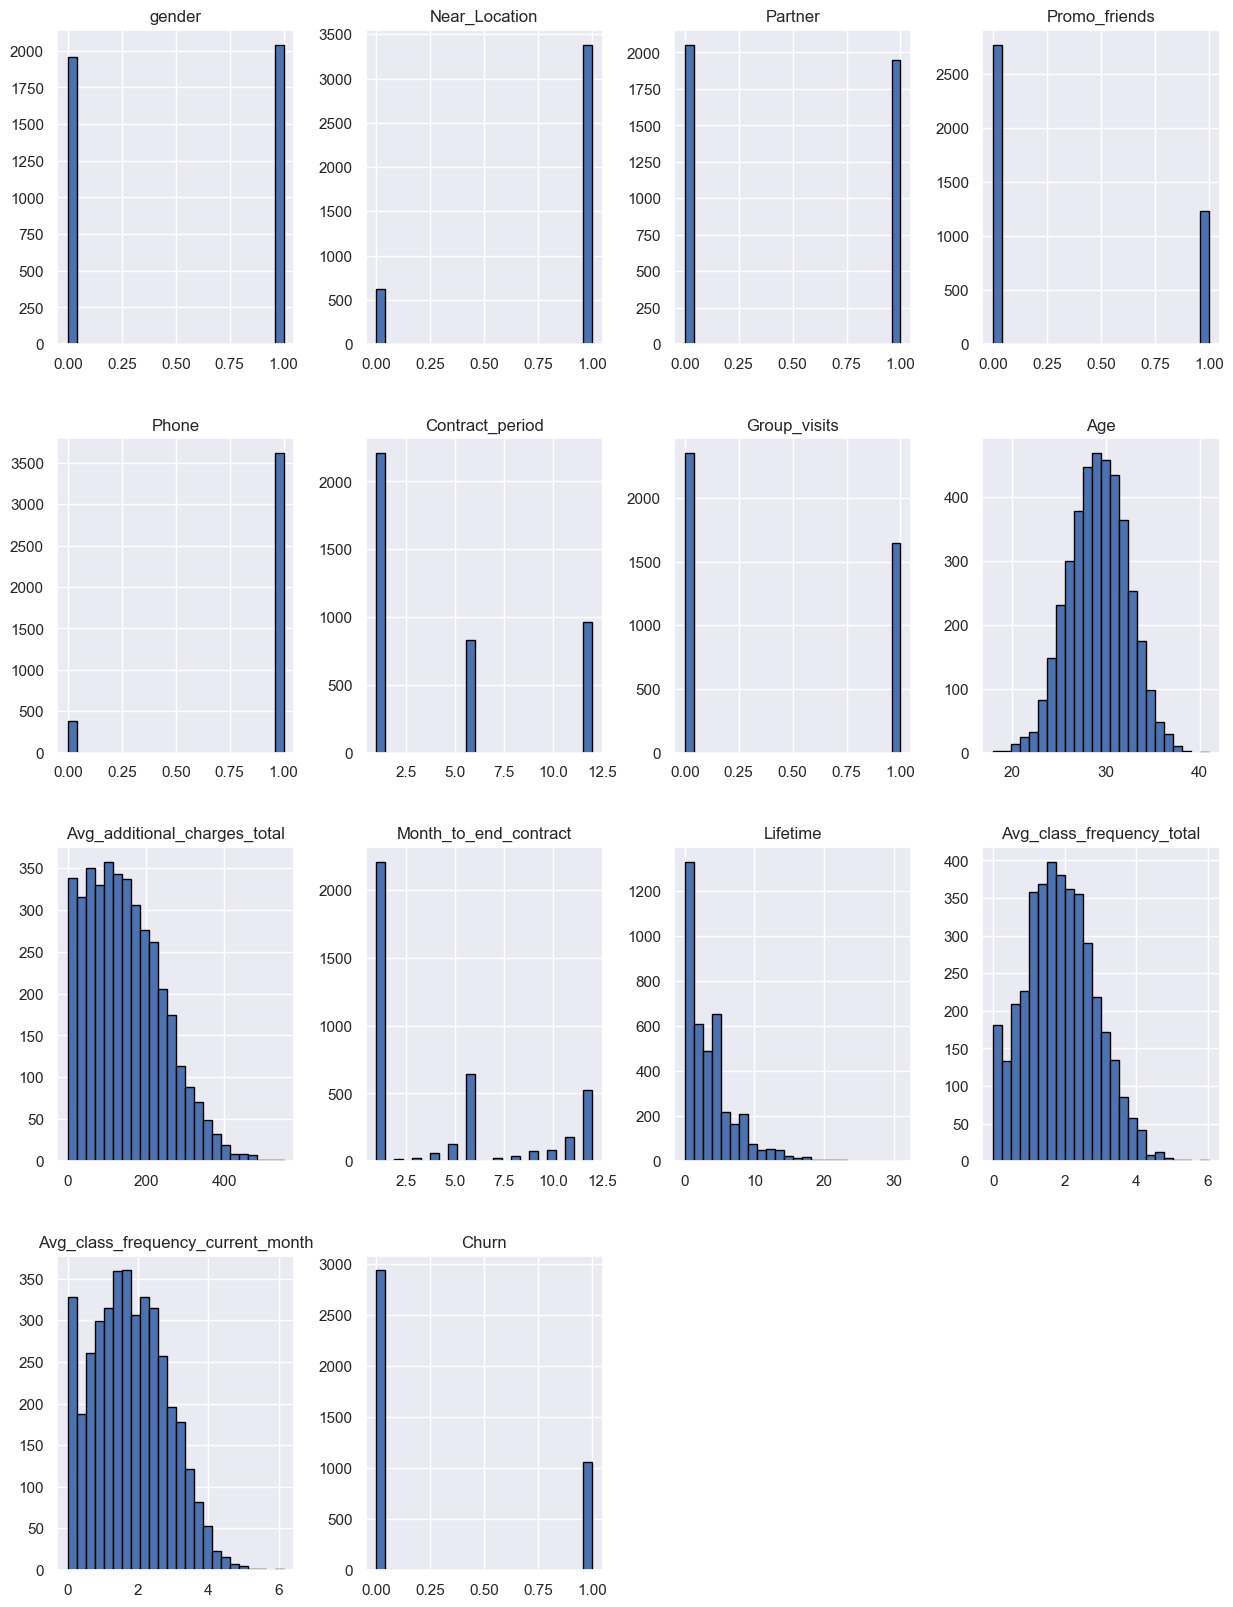

In [4]:
first_look(df)

<b>Первые выводы:</b><br>    
1. В ДФ всего 4000 записей. Полагаю, достаточно для проведения анализа.
2. Дубли и пропуски в данных не обнаружены.
3. Типы данных колонок имело бы смысл привести к типу, `bool` (`gender`, `Near_Location`, `Partner`, `Promo_friends`, `Phone`, `Group_visits`, `Churn`), но в нашем случае не актуально - оставим как есть.
4. Наименования колонок стоит привести к нижнему регистру.
5. По половому признаку ДФ разбит почти поровну (51% и 49%).
6. Большая часть пользователей проживают или работают рядом с фитнес-центром.
7. Чуть менее половины пользователей являются сотрудниками компаний-партнеров фитнес-центров (почти 48.7%).
8. Чуть менее трети пользователей участвовали в акции "приведи друга" (почти 31%).
9. Большая часть договоров была заключена на 1 месяц - 2207 шт., на год было заключено 960 контроктов, на полгода - 833шт.
10. В групповых занятиях участвовали 41% посетителей.
11. Возраст посетителей в ДФ варьируется от 18 лет до 41 года. Большая часть пользователей от 23 до 35 лет с пиком в 29 лет.
12. Средняя выручка от других услуг фитнес-центра на посетителя составляет 146 ед.
13. Срок действия абонементов повторяет график с периодами заключения договоров преимещественно. Пики находятся: на 1 месяце до окончания действия абонемента - 2207 шт., на 6 месяцах - 645 шт. и 12 месяцах - 524 абонемента.
14. Большая часть посетителей пришла впервые в зал чуть больше месяца после начала анализируемого периода - 843. Посетителей, которые впервые пришли в фитнес-центр меньше месяца до начала анализируемого периода - 487. 610 пользователей занимаются 2 масяца, 490 пользователей - 3 месяца. Далее количество пользователей с каждым месяцем падает. На данный момент, в ДФ данные за 31 месяц (2.5 года).
15. Средняя частота посещений фитнес-центров за всё время - 1.9 раз в неделю. За предыдущий месяц - 1.8 раз в неделю.
16. Доля оттока за последний месяц составила 26.5%

In [5]:
# Приводим названия колонок к нижнему регистру
df.columns=df.columns.str.lower()            

# Определяем список колонок, которые переводим в тип 'bool':
bool_list = ['gender', 'near_Location', 'partner', 'promo_friends', 'phone', 'group_visits', 'churn'] 
print(bool_list)

""" Присваивать колонкам тип данных 'bool' не будем, так как это ничего не даст, 
кроме необходимости обратной операции для отображения графиков. 
Закомменчу метод, которым пробовал перевести в тип 'bool' """
#try:
#    df[bool_list] = df[bool_list].astype('bool') 
#except KeyError:
#    pass

# Выводим названия колонок после преобразования к нижнему регистру:
print(#df.dtypes,
     '\n'*3,
    df.columns)


['gender', 'near_Location', 'partner', 'promo_friends', 'phone', 'group_visits', 'churn']



 Index(['gender', 'near_location', 'partner', 'promo_friends', 'phone',
       'contract_period', 'group_visits', 'age',
       'avg_additional_charges_total', 'month_to_end_contract', 'lifetime',
       'avg_class_frequency_total', 'avg_class_frequency_current_month',
       'churn'],
      dtype='object')


In [6]:
df.groupby(by='churn').agg('mean').T.rename(columns={0:'остались', 1:'ушли'})

churn,остались,ушли
gender,0.5100,0.5108
near_location,0.8731,0.7681
partner,0.5342,0.3553
promo_friends,0.3535,0.1838
phone,0.9037,0.9029
contract_period,5.7472,1.7286
group_visits,0.4641,0.2686
age,29.9765,26.9896
avg_additional_charges_total,158.4457,115.0829
month_to_end_contract,5.2831,1.6626


In [7]:
#Актуализируем список bool_list: 
bool_list = [i.lower() for i in bool_list]

# Удалим из списка колонку с оттоком:
churn_index = bool_list.index('churn')
bool_list.pop(churn_index)
print(bool_list)

['gender', 'near_location', 'partner', 'promo_friends', 'phone', 'group_visits']


In [8]:
# Заведем словарь с русским обозначением колонок для лучшего отображения графиков.
# таблицы менять не буду - ничем хорошим это не закончится:
columns_dict = {
    'gender':'Пол',
    'near_location':'Близость фитнес-центра\n к дому или работе',
    'partner':'Посетитель - сотрудник \nкомпании-партнёра клуба',
    'promo_friends':'По акции «приведи друга»',
    'phone':'Наличие контактного телефона',
    'age':'Возраст',
    'lifetime':'Время с момента первого \nобращения в фитнес-центр (в месяцах)',
    'contract_period':'Длительность текущего \nдействующего абонемента',
    'month_to_end_contract':'Срок до окончания текущего \nдействующего абонемента (в месяцах)',
    'group_visits': 'Посещение групповых занятий',
    'avg_class_frequency_total':'Частота посещений в неделю за \nвсе время с начала действия абонемента',
    'avg_class_frequency_current_month':'Средняя частота посещений \nв неделю за предыдущий месяц',
    'avg_additional_charges_total':'Средняя выручка от сторонних\n услуг фитнес-центра'
    }

#Разобьём дф на 2 по признаку оттока:
stayed = df[df['churn'] == 0].drop('churn', axis=1)
left = df[df['churn'] == 1].drop('churn', axis=1)

# Заведем словарь с количеством столбов на графике, чтобы удобнее было смотреть визуализации: 
dict_bins = {'age':21,
'lifetime':32,
'contract_period':5,
'month_to_end_contract':12,
'avg_class_frequency_total':8,
'avg_class_frequency_current_month':8,
'avg_additional_charges_total':30}

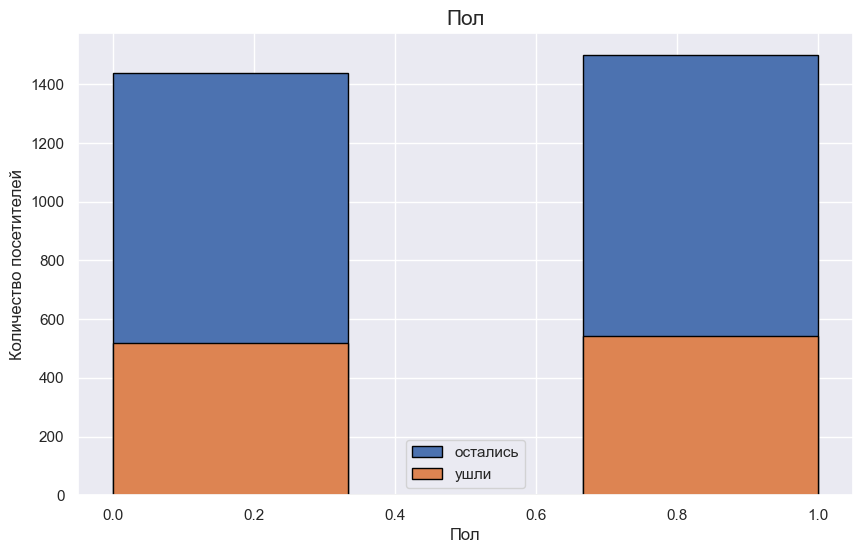

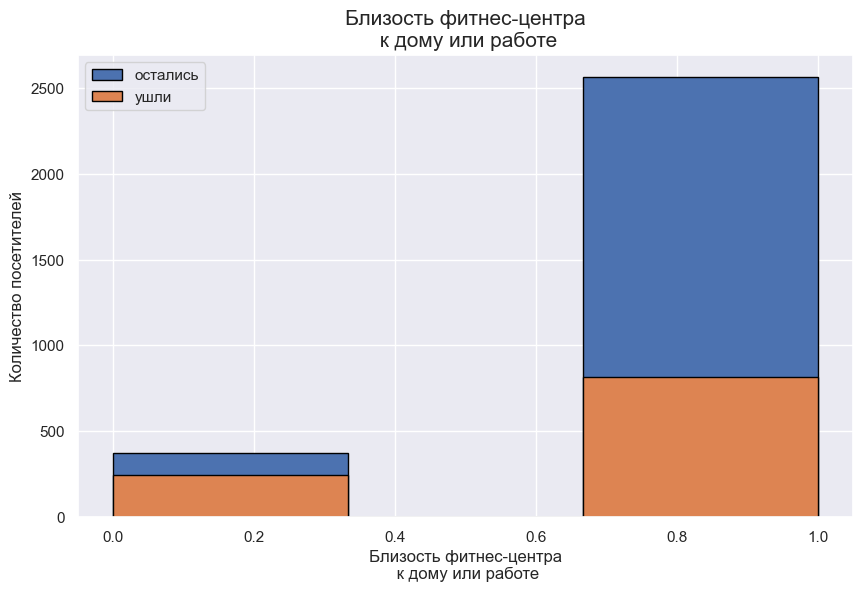

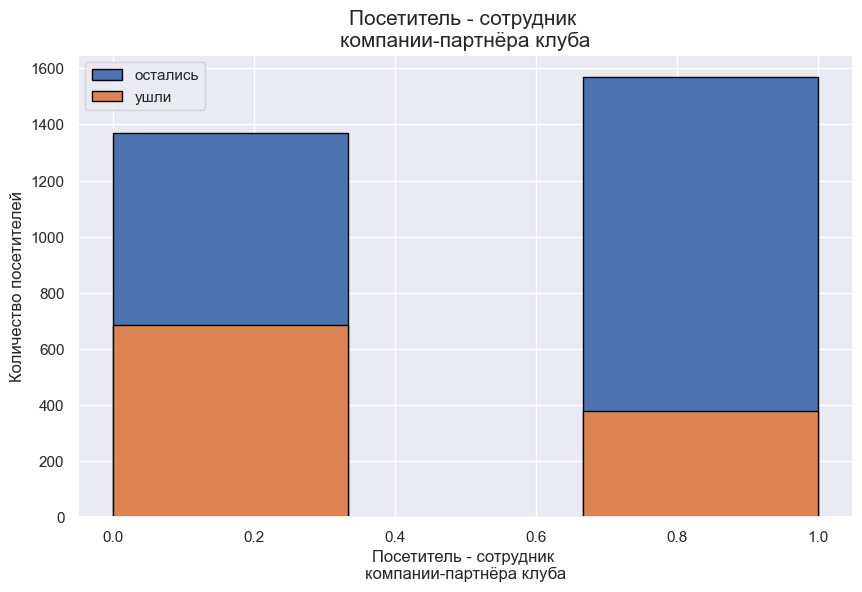

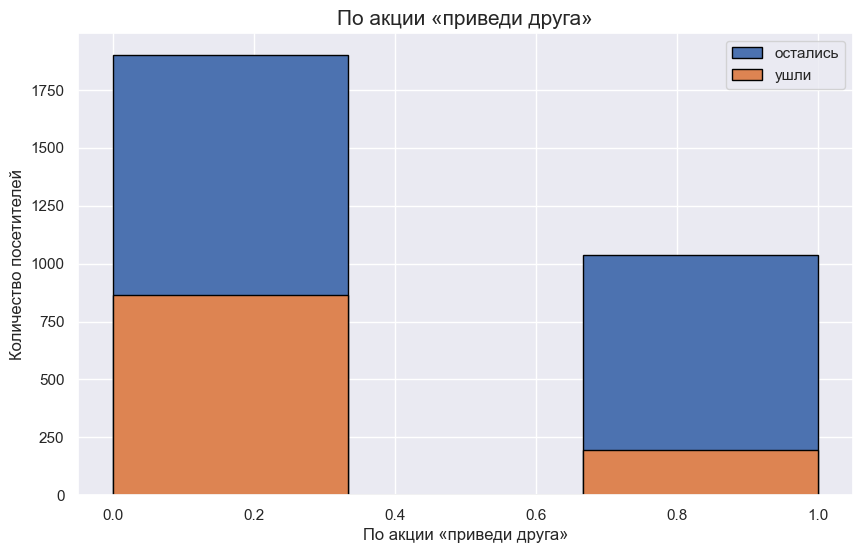

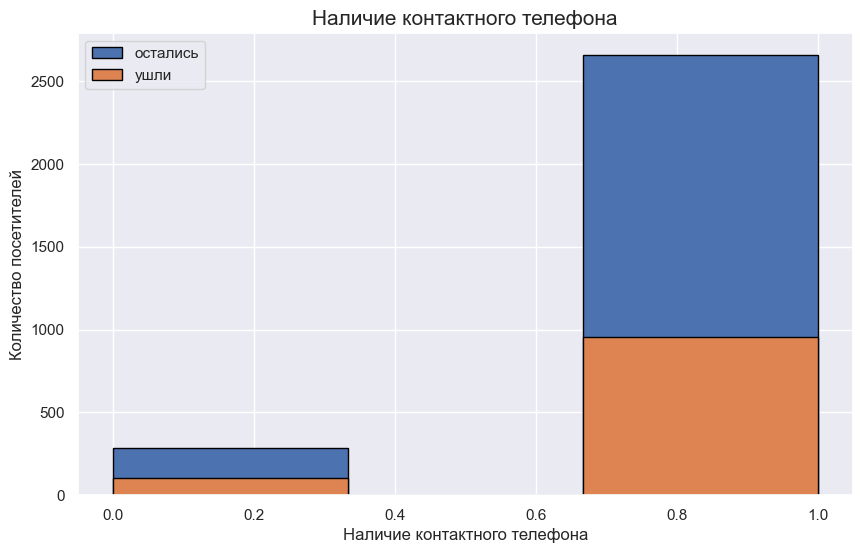

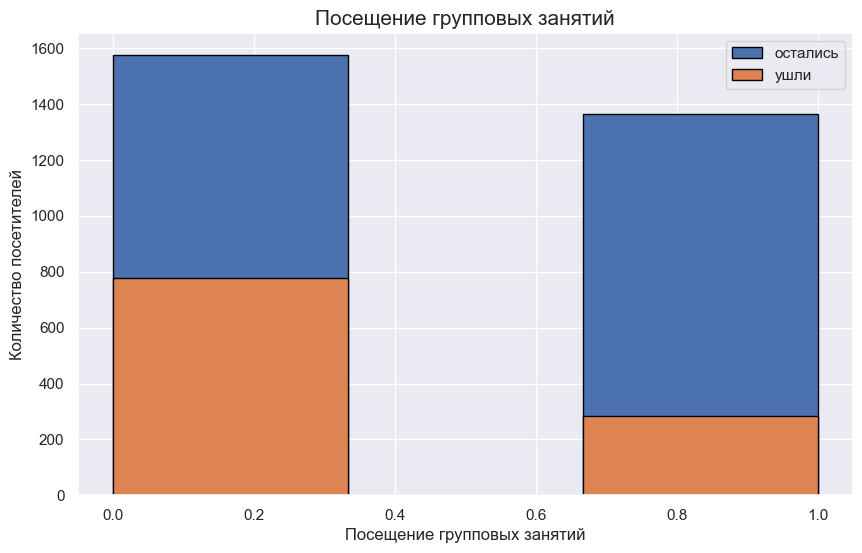

In [9]:
# Выведем гистограммы по колонкам, тип которых соответствует bool:
for column in bool_list:
    df.groupby('churn')[column].hist(edgecolor = 'black', bins=3)

    plt.title(columns_dict.get(column), fontsize=15)       
    plt.xlabel(columns_dict.get(column), fontsize=12)
    plt.ylabel('Количество посетителей', fontsize=12)
    plt.legend(['остались','ушли'])

    plt.show()    

In [10]:
#Заведем список колонок, в которых более 2 различных значений:
not_bool_list = list(df.columns[~df.columns.isin(bool_list)])
not_bool_list

# Удалим из списка колонку с оттоком:
churn_index = not_bool_list.index('churn')
not_bool_list.pop(churn_index)
not_bool_list

['contract_period',
 'age',
 'avg_additional_charges_total',
 'month_to_end_contract',
 'lifetime',
 'avg_class_frequency_total',
 'avg_class_frequency_current_month']

C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


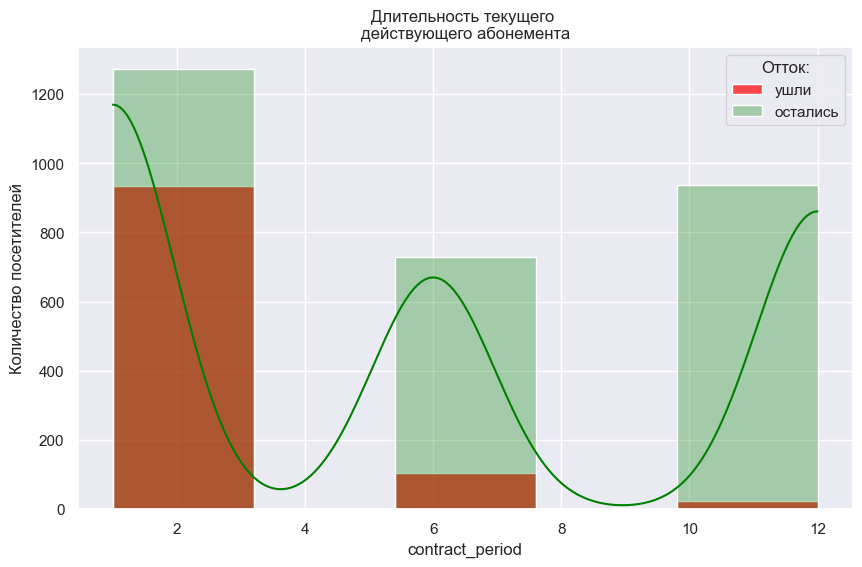

C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


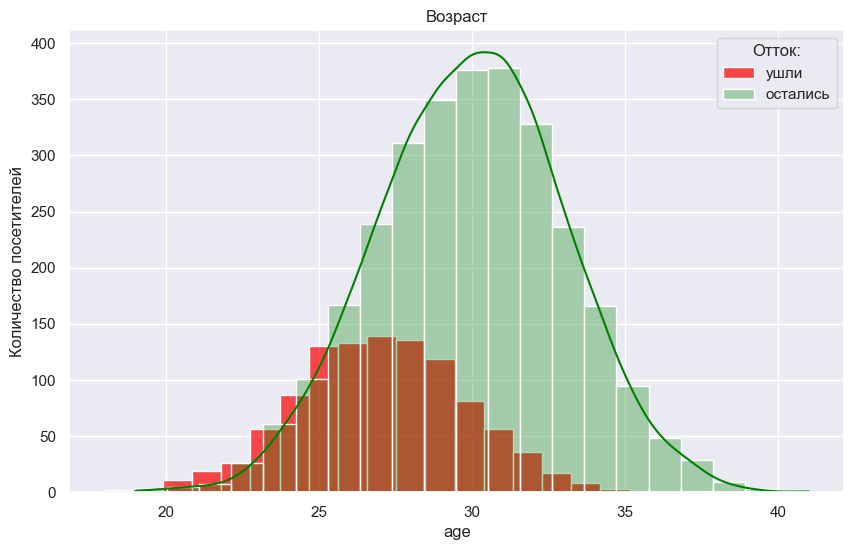

C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


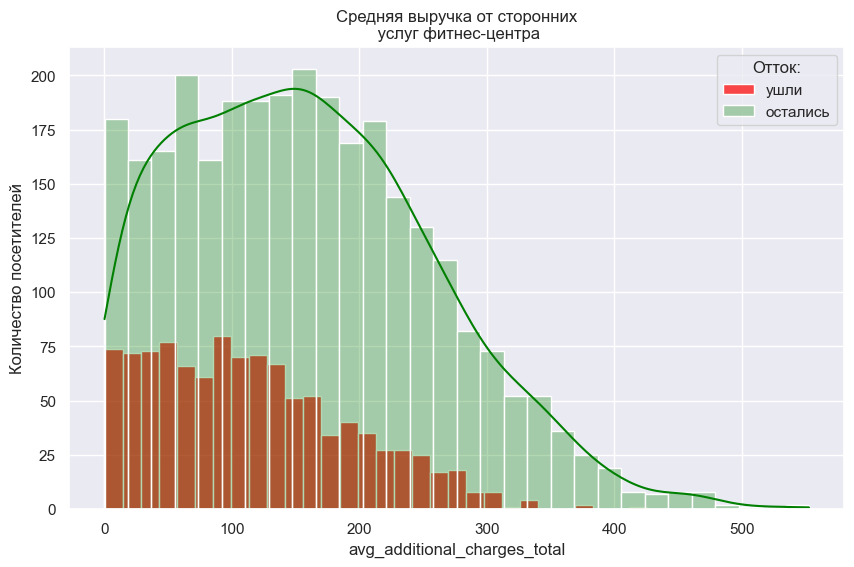

C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


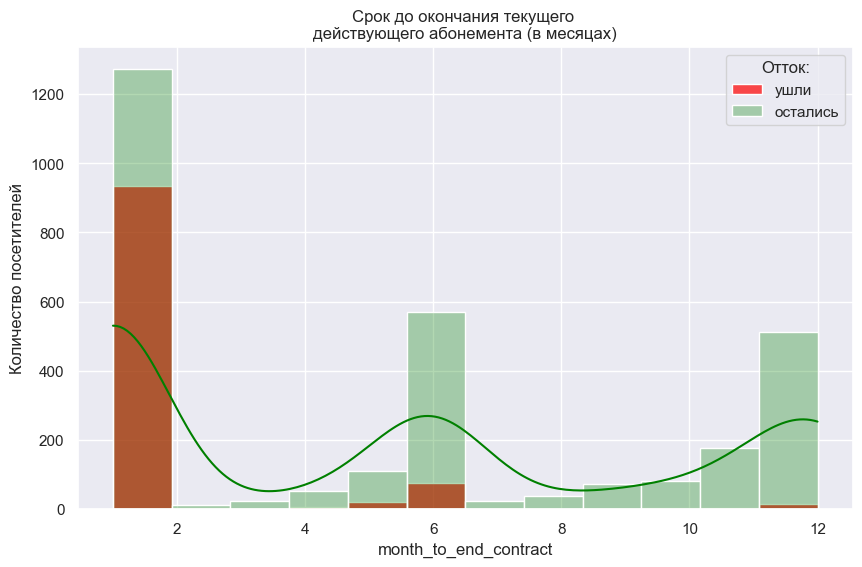

C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


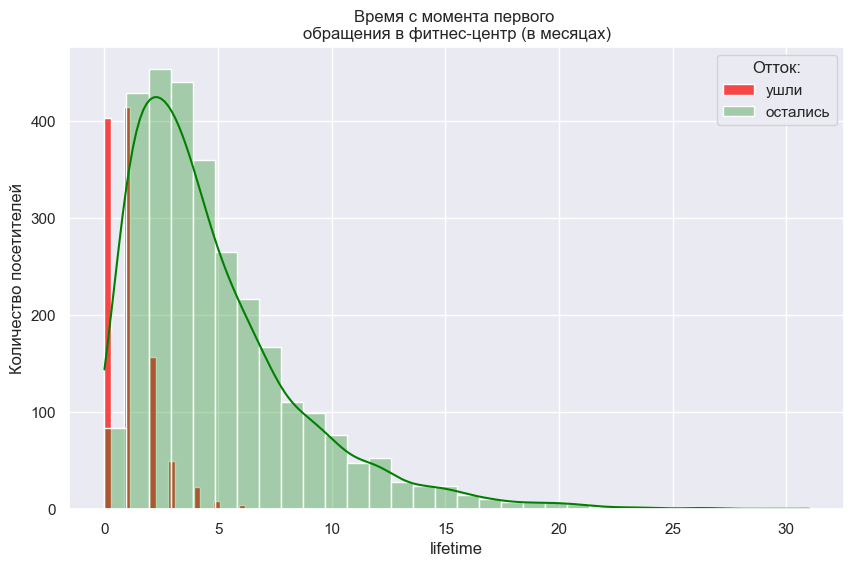

C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


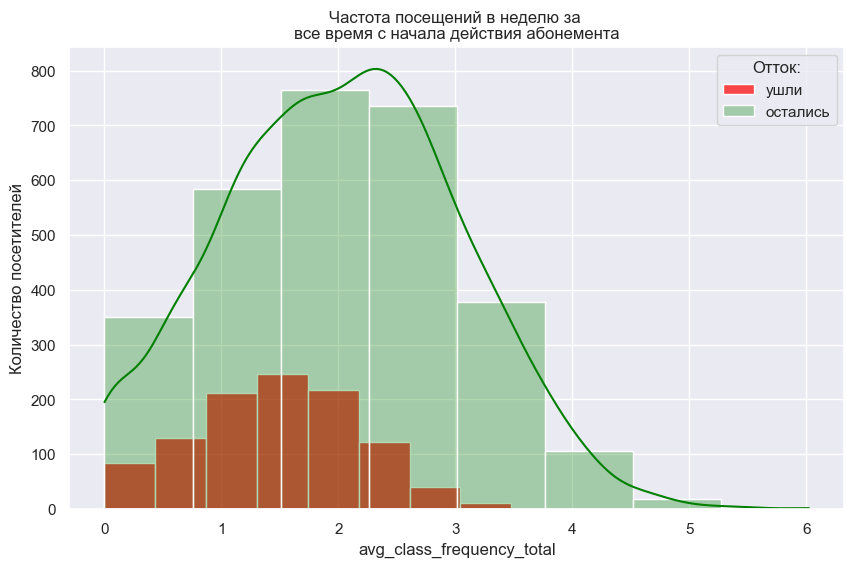

C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


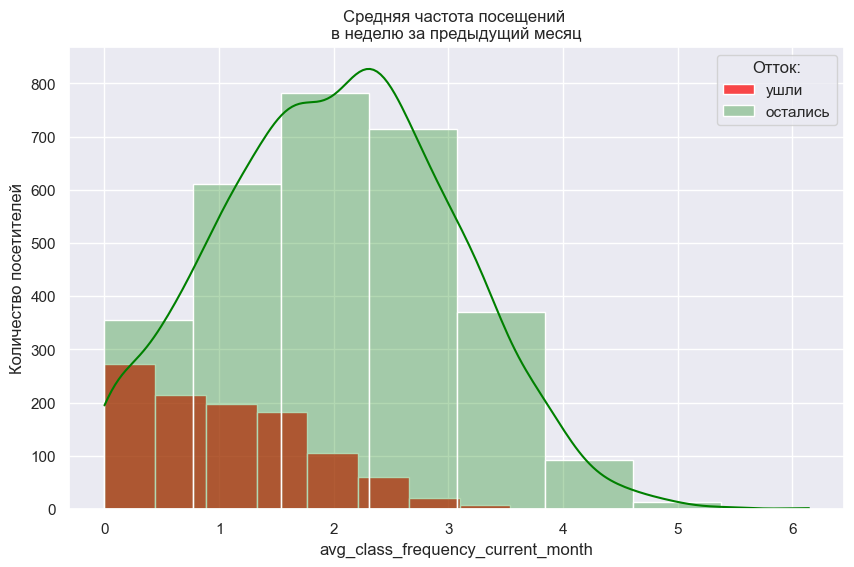

In [11]:
#Диаграммы, где количество значений больше 2 (не bool): 
for column in not_bool_list:
    sns.histplot(data = left[column], color = 'red', label = 'ушли', alpha = 0.7, bins =  dict_bins.get(column), kde=False)
    sns.histplot(data = stayed[column], color = 'green', label = 'остались', alpha = 0.3, bins = dict_bins.get(column), kde=True)

    plt.title(columns_dict.get(column))        
    #plt.xlabel(columns_dict.get(column))
    plt.ylabel('Количество посетителей')
    plt.legend(title='Отток:')

    plt.show()

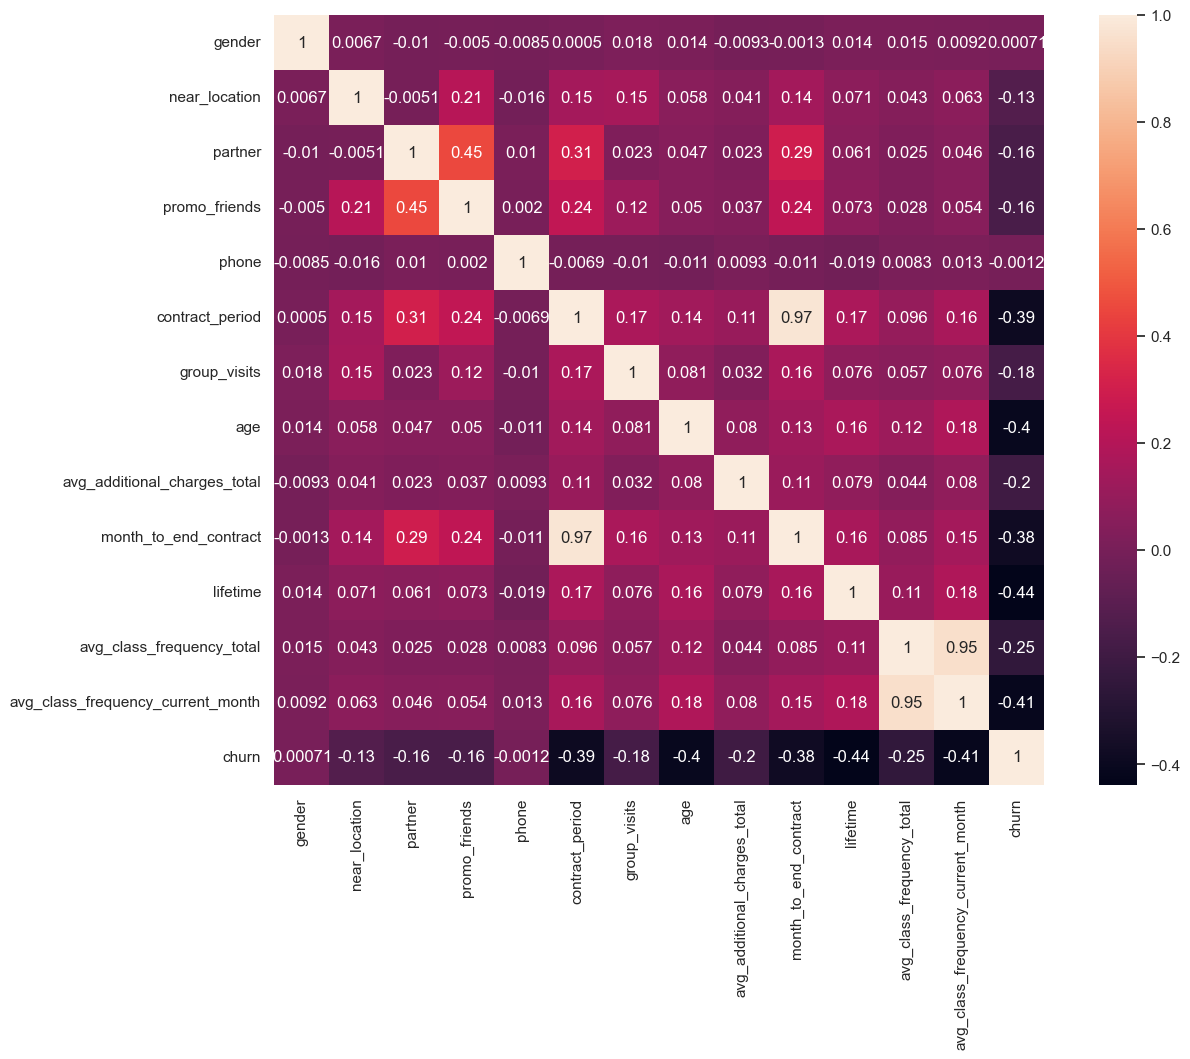

In [12]:
# Выведем тепловую карту таблицы корреляции:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), square = True, annot = True)
plt.show()

<b>Вывод:</b><br>
`По половому признаку`: В целом, нет особой разницы. разбивка примерно 50/50, полагаю в любом разрезе.<br>
`По удаленности фитнесс-центра от дома или места работы`: По большей части, те кто остались проживают или ряботают рядом с фитнес-центром. Среди ушедших, также наблюдается 815 пользователей, которые не далеко от фитнес центра работают или проживают. Значит прекратили посещать по другой причине.<br> 
`Посетитель - сотрудник компании-партнера клуба`: В целом, доля "партнеров" и "не партнеров" составляет примерно 50/50, однака распределение среди них между ушедшими и оставшимися разительно отличается, так разница среди "не партнеров" примерно 1 к 2, то среди партнеров оставшихся примерно в 4 раз больше.  <br> 
`По акции "приведи друга"`:
Большая часть пользователей пренебрегла услугой, тем не менее среди тех кто воспользовался, доля оставшихся значительно выше тех, кто прекратил посещать зал.
`По наличию контактного телефона`:
В целом, доля посетителей, не указавших номер телефона для связи, крайне низка. Примерная разница 1/2.5  
`По посещению групповых занятий`: 
Большая часть посетителей игнорирует групповые занятия, но при этом, те, кто посещают, имеют склонность к тому, чтобы не покидать фитнес-центр.
`По длительности действия договора`: Большая часть людей, которая предпочла уйти, сделала это после окончания действия абонемента на месяц. Возможно, им зал не подошел по какой-то причине.<br>
`По возрасту`: Чем старше посетители, тем менее актуальна для них смена спорт-зала. Пик оттока приходится на 27 летних, при этом интервал 25-29 лет не сильно разнится между собой и исключительность 27 летних весьма условна. Пик оставшихся находится в районе 30 летних среди посетителей.<br>
`По средней выручке от сторонних услуг`: В некоторых случаях, пользователи, которые не ушли из сети фитнес-центров, тратили больше денег, чем те, которые ушли.  
<br>
`По продолжительности контрактов`: Вполне естественно, что те, кто берут абонемент в фитнес-центр, в меньшей степени уходят из него. Большая часть ушла после 1 месяца занятий.<br>
`По времени с момента первого обращения`: Большая часть пользователей - новая, при этом отток прекратил ходить через 1-3 месяца после начала преимущественно (больше всего через 2 месяца). Среди тех кто не ушел, можно отменить, что большая часть также новенькие и занимаются примерно чуть больше полугода.<br>
`По количеству посещений в неделю`: Среди тех кто решил прекратить посещать фитнес-центр, наблюдается сниженная интенсивность посещений, по сравнению с теми, кто не ушел.   

Есть несколько колонок у которых сильно выражена корреляция между собой:<br>
`month_to_end_contract` и `contract_period`, <br>
`avg_class_frequency_total` и `avg_class_frequency_current_month`.<br>
Полагаю, имеет смысл убрать лишние колонки из дальнейшей обработки, чтобы они не дублировали влияние на модель.
Уберу `month_to_end_contract` и `avg_class_frequency_total`, но сделаю с несколько дополнительных дф, не редактируя актуальную и проверю результат.



In [13]:
# Размер дф до удаления колонок:
print(f'Размер дф до удаления колонок : {df.shape[0]} строк на {df.shape[1]} колонок')

Размер дф до удаления колонок : 4000 строк на 14 колонок


In [14]:
#Сокращение колонок с высокой корреляцией:
df_no_2 = df.drop(['month_to_end_contract', 'avg_class_frequency_total'], axis=1)# Обе колонки долой
df_no_mtec = df.drop('month_to_end_contract', axis=1) # Без срока окончания договора 
df_no_acft = df.drop('avg_class_frequency_total', axis=1) # Без среднего посещения за период
# Размер дф после удаления колонок:
print(f'Размер дф после удаления двух колонок : {df_no_2.shape[0]} строк на {df_no_2.shape[1]} колонок')
print(f'Размер дф после удаления колонки со сроком договора : {df_no_mtec.shape[0]} строк на {df_no_mtec.shape[1]} колонок')
print(f'Размер дф после удаления колонки со средними посещениями за период: {df_no_acft.shape[0]} строк на {df_no_acft.shape[1]} колонок')

Размер дф после удаления двух колонок : 4000 строк на 12 колонок
Размер дф после удаления колонки со сроком договора : 4000 строк на 13 колонок
Размер дф после удаления колонки со средними посещениями за период: 4000 строк на 13 колонок


### Построение модели прогнозирования оттока клиентов


In [15]:
# Определим функцию:
def test(df):
    # разделяем данные на признаки (матрица X) и целевую переменную (y):
    X = df.drop(['churn'], axis = 1)
    y = df['churn']

    # разделяем модель на обучающую и валидационную выборку:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # стандартизируем данные: 
    scaler = StandardScaler()
    scaler.fit(X_train) # обучаем scaler на обучающей выборке методом fit
    X_train_st = scaler.transform(X_train) # стандартизируем обучающую выборку методом transform scaler 
    X_test_st = scaler.transform(X_test) # стандартизируем тестовую выборку методом transform scaler

    # зададим алгоритм для модели логистической регрессии:
    lr_model = LogisticRegression(random_state=42) 

    # обучим модель логистической регрессии:
    lr_model.fit(X_train_st,y_train)

    # воспользуемся уже обученной моделью, чтобы сделать прогнозы
    lr_predictions = lr_model.predict(X_test_st)
    lr_probabilities = lr_model.predict_proba(X_test_st)[:,1]

    # выведем метрики для полученного прогноза логистической регрессии:
    print('Метрики для полученного прогноза логистической регрессии:')
    print(f'Accuracy: {accuracy_score(y_test, lr_predictions):.4f}')
    print(f'Precision: {precision_score(y_test, lr_predictions):.4f}')
    print(f'Recall: {recall_score(y_test, lr_predictions):.4f}')

    # зададим алгоритм для модели случайного леса:
    rf_model = RandomForestClassifier(n_estimators = 100, random_state=42) 

    # обучим модель случайного леса:
    rf_model.fit(X_train_st,y_train)

    # воспользуемся уже обученной моделью, чтобы сделать прогнозы
    rf_predictions = rf_model.predict(X_test_st)
    rf_probabilities = rf_model.predict_proba(X_test_st)[:,1]

    # выведем метрики для полученного прогноза случайного леса:

    print('\nМетрики для полученного прогноза случайного леса:')
    print(f'Accuracy: {accuracy_score(y_test, rf_predictions):.4f}')
    print(f'Precision: {precision_score(y_test, rf_predictions):.4f}')
    print(f'Recall: {recall_score(y_test, rf_predictions):.4f}')

Проверим какой дф даёт лучший результат по показателям:

In [16]:
print('Рассмотрим полную дф:')
test(df)
print('\n',
      '-\\-'*10,
      '\n'*2,
      'Рассмотрим дф после удаления 2х колонок:')
test(df_no_2)
print('\n',
      '-\\-'*10,
      '\n'*2,
      'Рассмотрим дф Без срока окончания договора:')
test(df_no_mtec)
print('\n',
      '-\\-'*10,
      '\n'*2,
      'Рассмотрим дф Без среднего посещения за период:')
test(df_no_acft)

Рассмотрим полную дф:
Метрики для полученного прогноза логистической регрессии:
Accuracy: 0.9163
Precision: 0.8729
Recall: 0.7822

Метрики для полученного прогноза случайного леса:
Accuracy: 0.9100
Precision: 0.8495
Recall: 0.7822

 -\--\--\--\--\--\--\--\--\--\- 

 Рассмотрим дф после удаления 2х колонок:
Метрики для полученного прогноза логистической регрессии:
Accuracy: 0.9050
Precision: 0.8247
Recall: 0.7921

Метрики для полученного прогноза случайного леса:
Accuracy: 0.8875
Precision: 0.8182
Recall: 0.7129

 -\--\--\--\--\--\--\--\--\--\- 

 Рассмотрим дф Без срока окончания договора:
Метрики для полученного прогноза логистической регрессии:
Accuracy: 0.9163
Precision: 0.8729
Recall: 0.7822

Метрики для полученного прогноза случайного леса:
Accuracy: 0.9175
Precision: 0.8696
Recall: 0.7921

 -\--\--\--\--\--\--\--\--\--\- 

 Рассмотрим дф Без среднего посещения за период:
Метрики для полученного прогноза логистической регрессии:
Accuracy: 0.9050
Precision: 0.8281
Recall: 0.7871

М

<b>Вывод:</b><br>
Чем ближе `Accuracy`, `Precision` и `Recall` к 1, тем качественнее работает модель. 
Тут открывается интересная картина: 
1. Варианты дф `с удалением обеих колонок`, а так же удалением колонки `среднего посещения за период` отметаем сразу, так как в этих вариантах показатели ниже, чем в остальных дф.
2. Если рассматривать вариант дф без удаления колонок, то лучше себя показала модель логистической регрессии.
3. Если рассматривать вариант дф из которого удалена колонка со сроком окончания договора, то по 2м из 3х показателей модель случайного леса показала себя лучше, модели логистической регрессии.
<br>

<b>Я предпочту в дальнейшем работать именно с дф без колонки со сроком окончания договора и предпочту модель случайного леса.</b>

### Кластеризация клиентов

In [17]:
# разделяем данные на признаки (матрица X) и целевую переменную (y):
X = df_no_mtec.drop(['churn'], axis = 1)
y = df_no_mtec['churn']

# разделяем модель на обучающую и валидационную выборку:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

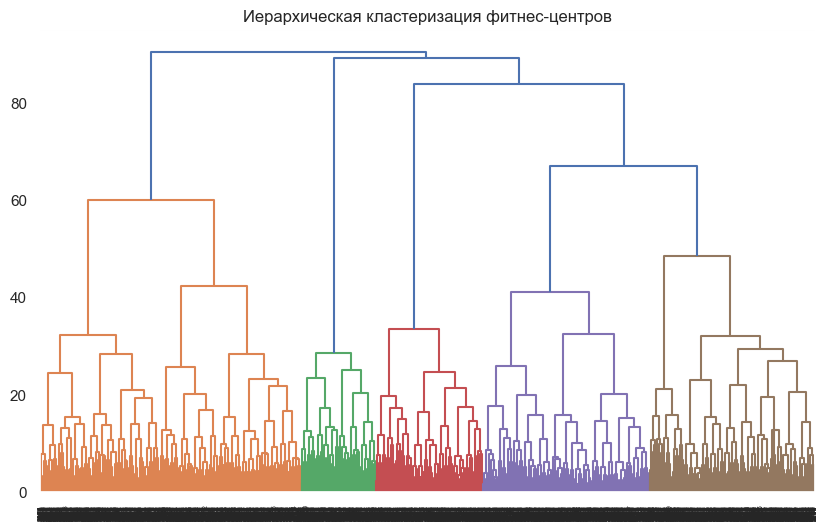

In [18]:
# Стандартизируем данные (на всякий случай еще раз):
sc = StandardScaler()
X_sc = sc.fit_transform(X)

#Построим матрицу расстояний:
linked = linkage(X_sc, method='ward')

# Построим дендрограмму:
dendrogram(linked, orientation='top')
plt.title('Иерархическая кластеризация фитнес-центров')
plt.show() 

На основании полученного графика, полагаю можно выделить 5 кластеров (по количеству цветов). Возможно, имеет смысл расширить до 6 кластеров.

In [19]:
# Задаём модель k_means с числом кластеров 5 и фиксируем значение random_state:
km = KMeans(n_clusters=5, random_state=42)

# Прогнозируем кластеры для наблюдений (алгоритм присваивает им номера от 0 до 4):
labels = km.fit_predict(X_sc)

# Сохраняем метки кластера в поле нашего датасета:
df_no_mtec['cluster_km'] = labels

# Выведем кластеры с количеством записей 
display(df_no_mtec.groupby(['cluster_km'])['gender'].count())

# Выводим статистику по средним значениям наших признаков по кластеру:
display(df_no_mtec.drop('churn', axis=1).groupby(by='cluster_km').agg('mean').T)

C:\Users\ageev\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


cluster_km
0     386
1    1069
2     714
3     988
4     843
Name: gender, dtype: int64

cluster_km,0,1,2,3,4
gender,0.5233,0.4790,0.5168,0.5476,0.4947
near_location,0.8627,0.6408,0.9454,0.8816,0.9692
partner,0.4715,0.1600,0.9566,0.1771,0.8731
promo_friends,0.3057,0.0056,0.7549,0.0466,0.6228
phone,0.0000,1.0000,1.0000,1.0000,1.0000
contract_period,4.7772,2.5529,9.2773,3.7581,4.5255
group_visits,0.4275,0.2900,0.5826,0.4423,0.3808
age,29.2979,28.1703,30.2129,30.0051,28.5848
avg_additional_charges_total,144.2082,130.3585,159.0892,162.8372,140.3137
lifetime,3.9404,2.2806,4.9846,4.8006,3.1293


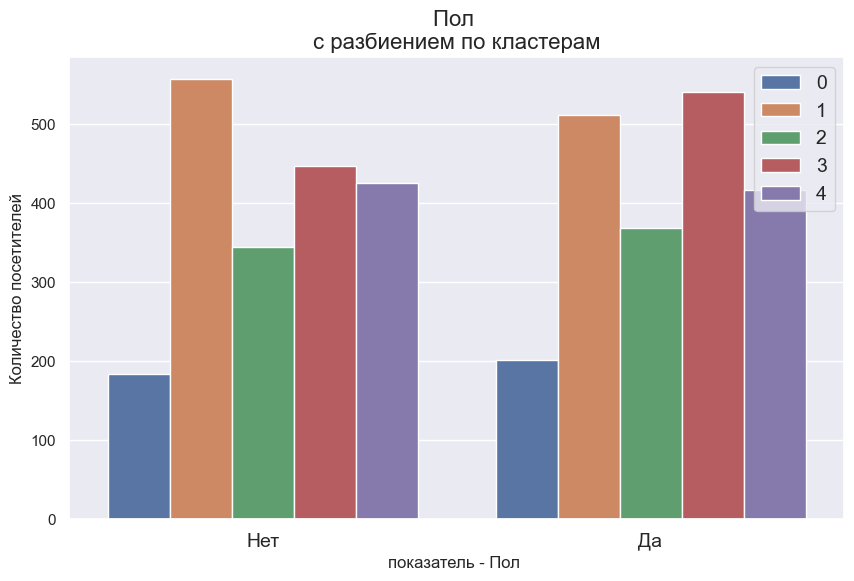

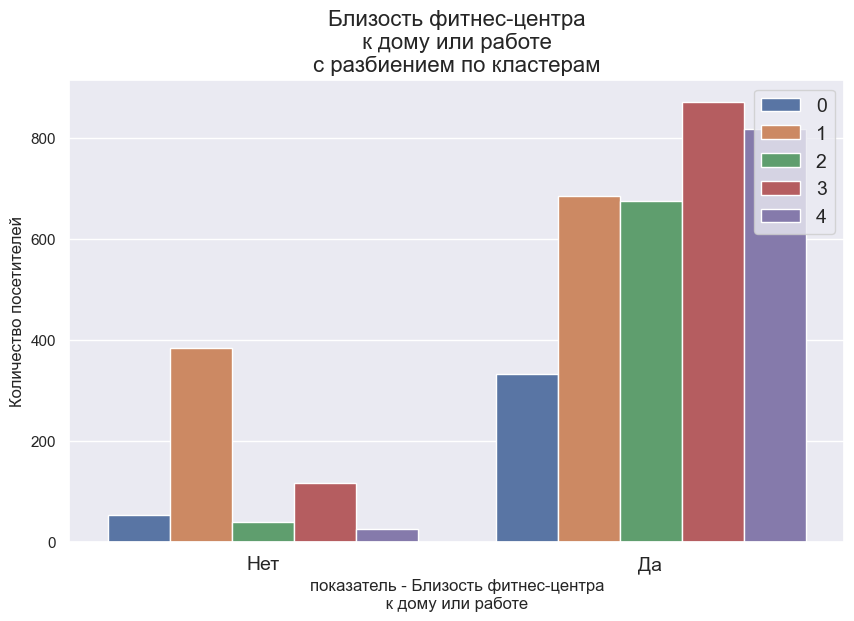

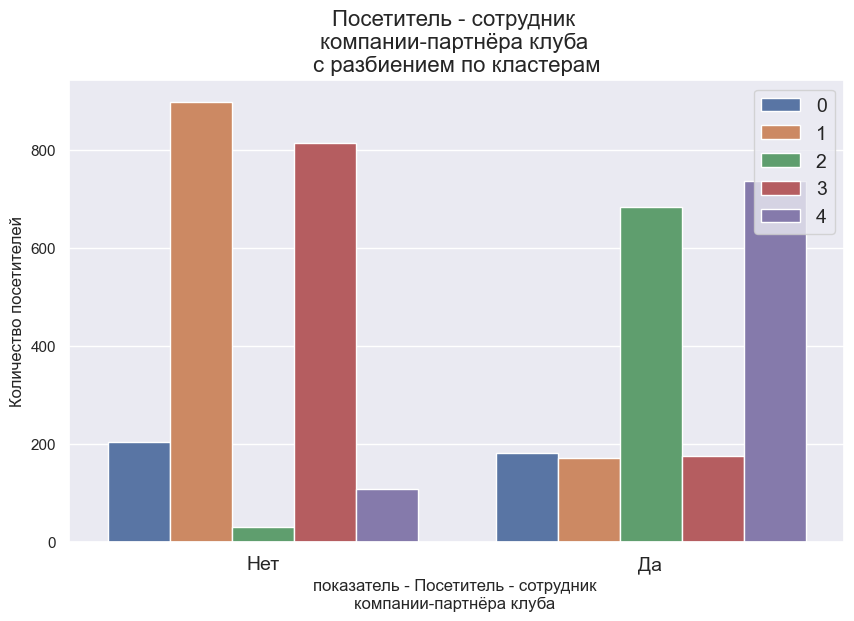

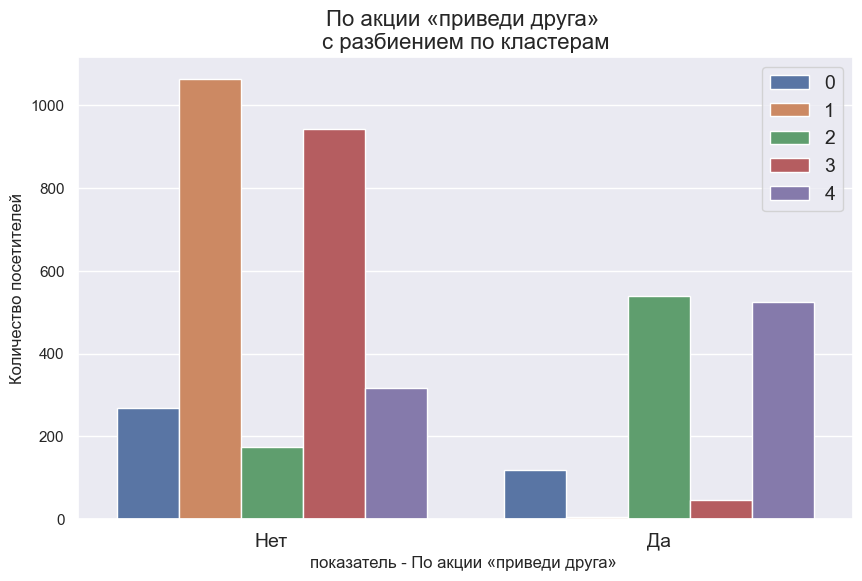

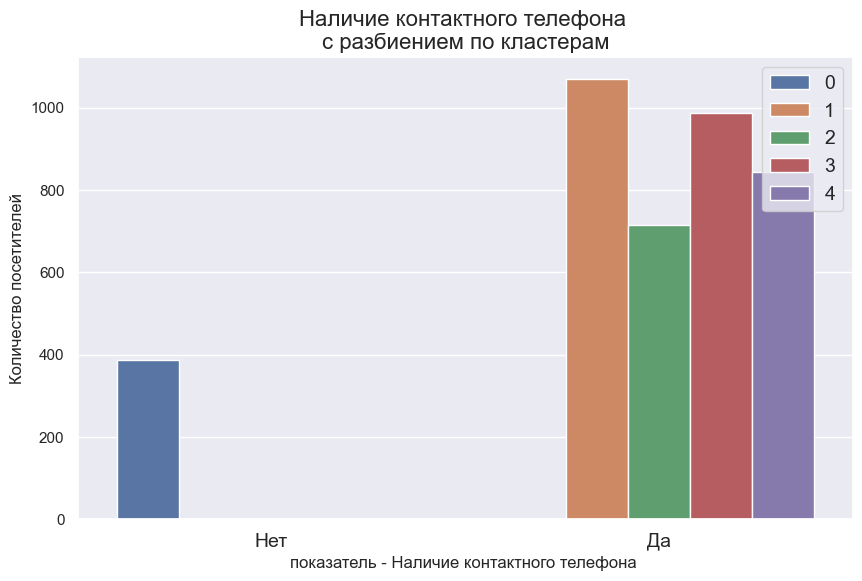

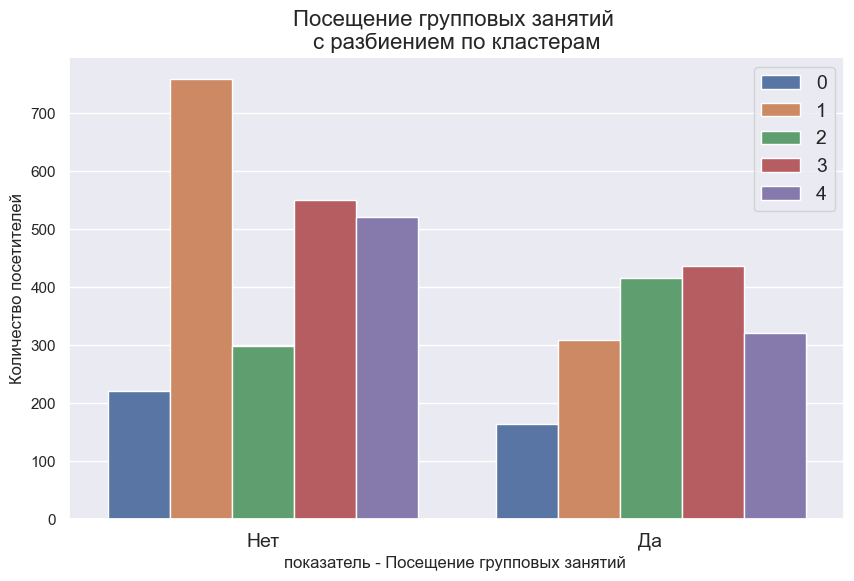

In [20]:
#Создам палитру для графиков (приблизительно стандартная расцветка):
colors=['#00688B', '#CD6600', '#228B22','#CD4F39', '#8B668B']

#Визуализирую сначала графики по колонкам с булевыми значениями (количественную):
for i in bool_list:
    ax=sns.countplot(data=df_no_mtec,x=i, hue='cluster_km')
    ax.set_title(f'{columns_dict.get(i)} \nс разбиением по кластерам', fontsize = 16)
    ax.set(ylabel='Количество посетителей', xlabel=f'показатель - {columns_dict.get(i)} ') 
    plt.xticks([0, 1], ('Нет', 'Да'), fontsize = 14)
    plt.legend(loc='upper right', fontsize = 14)
    plt.show()

C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


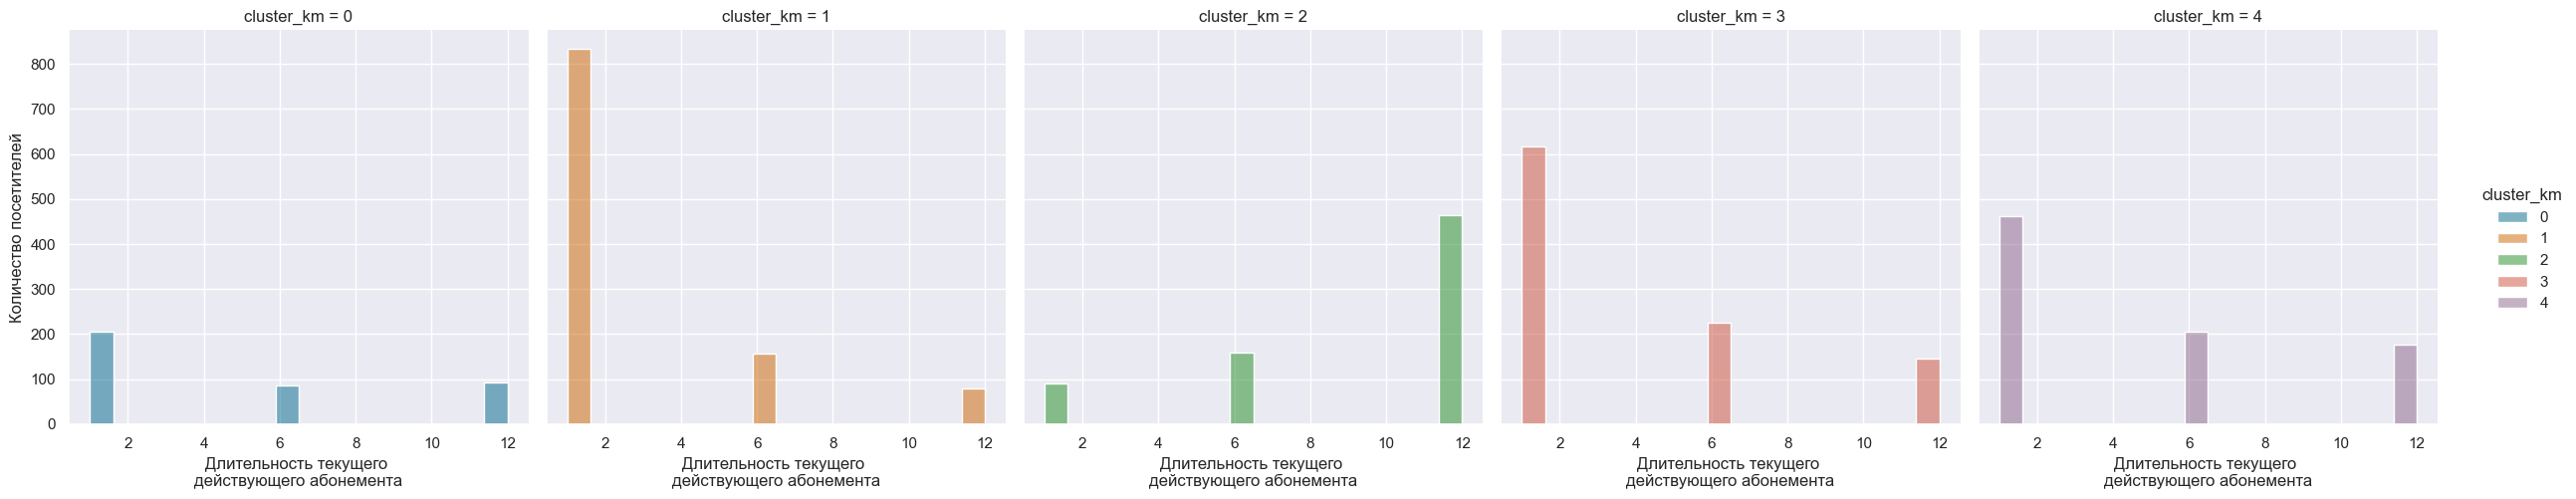

C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


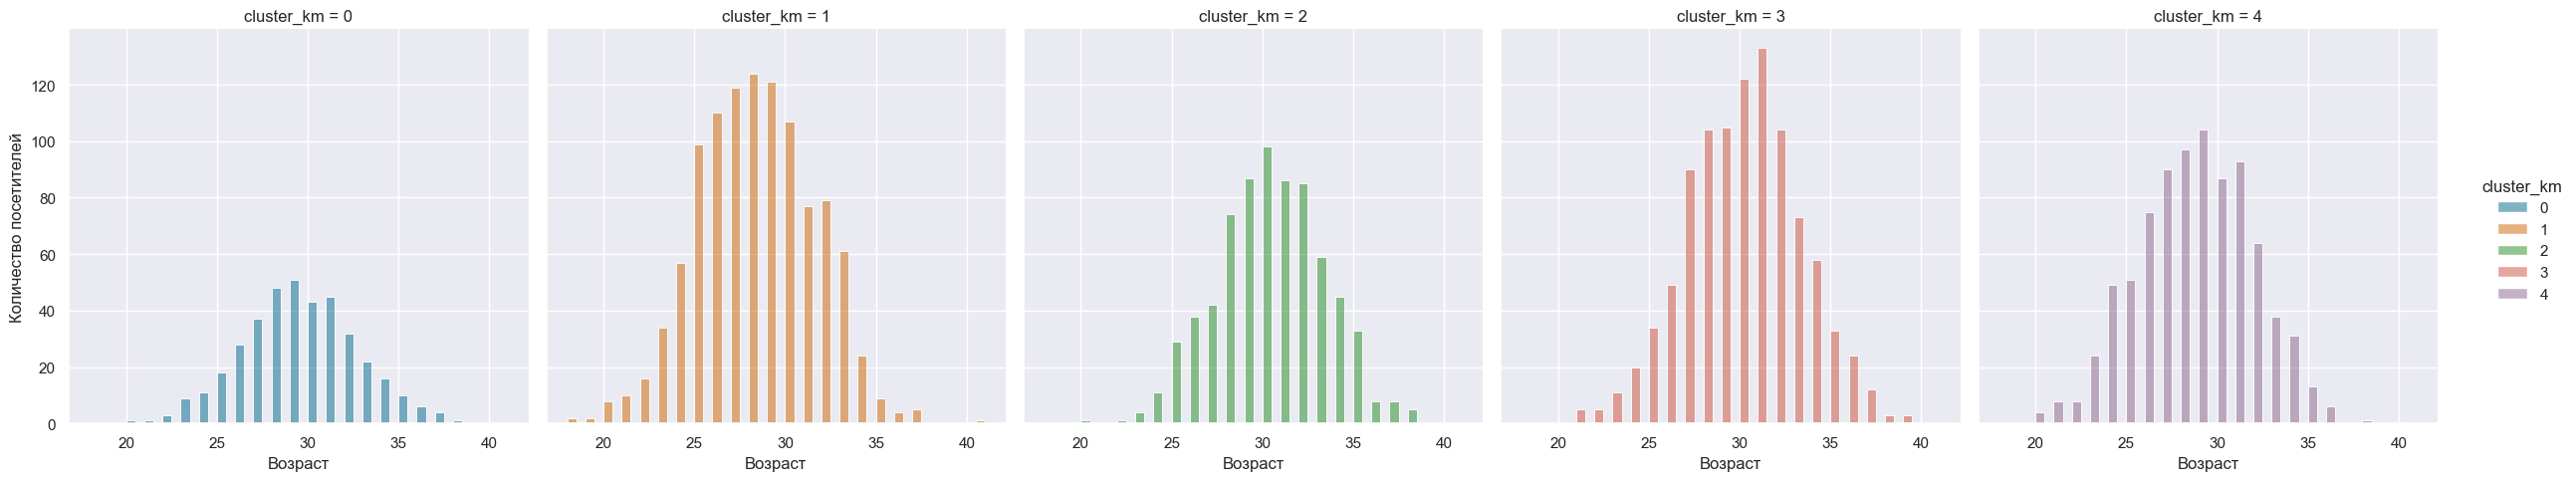

C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


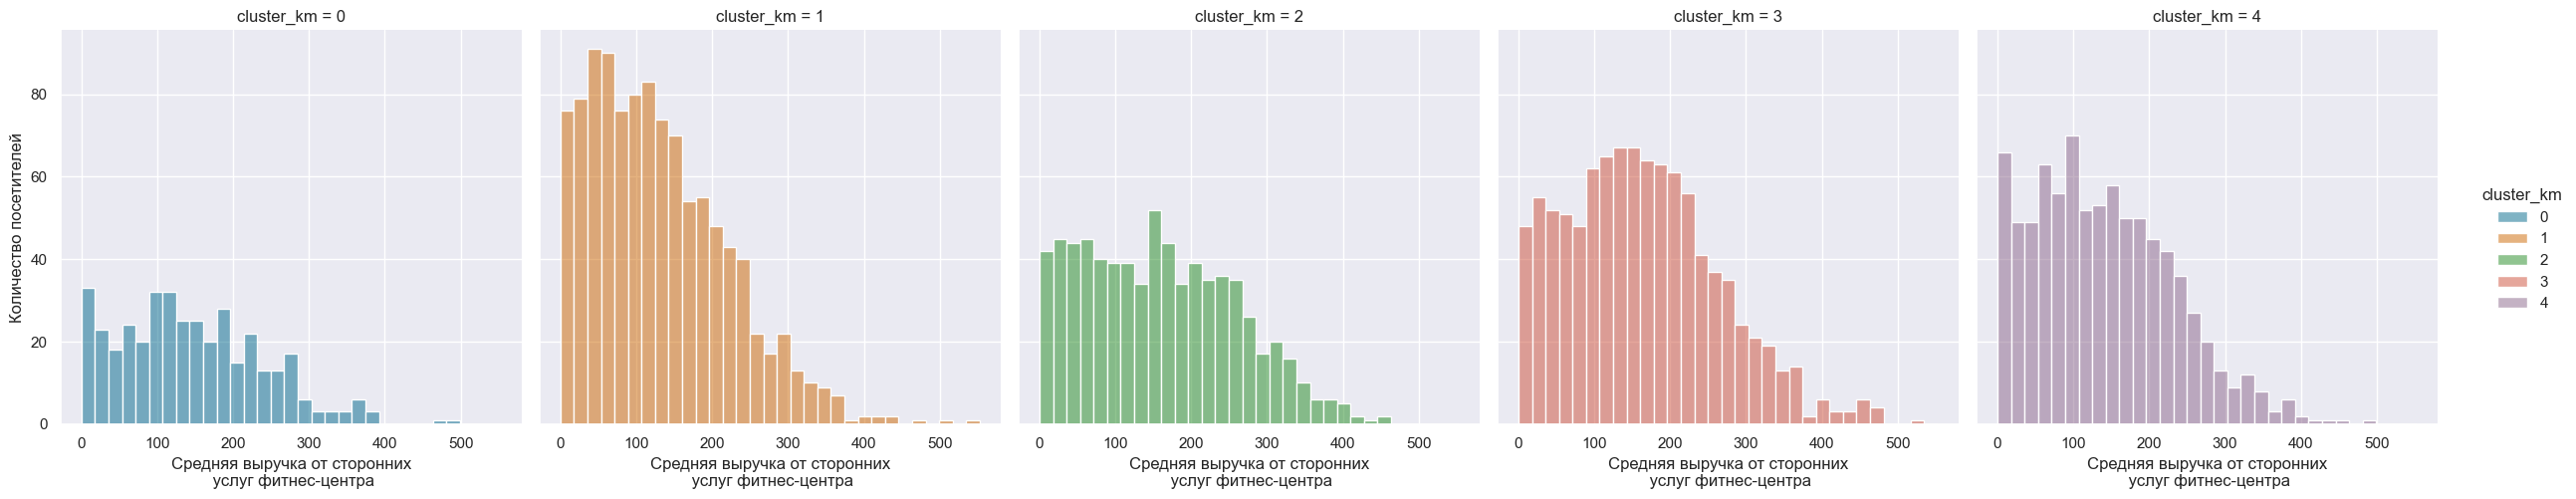

C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


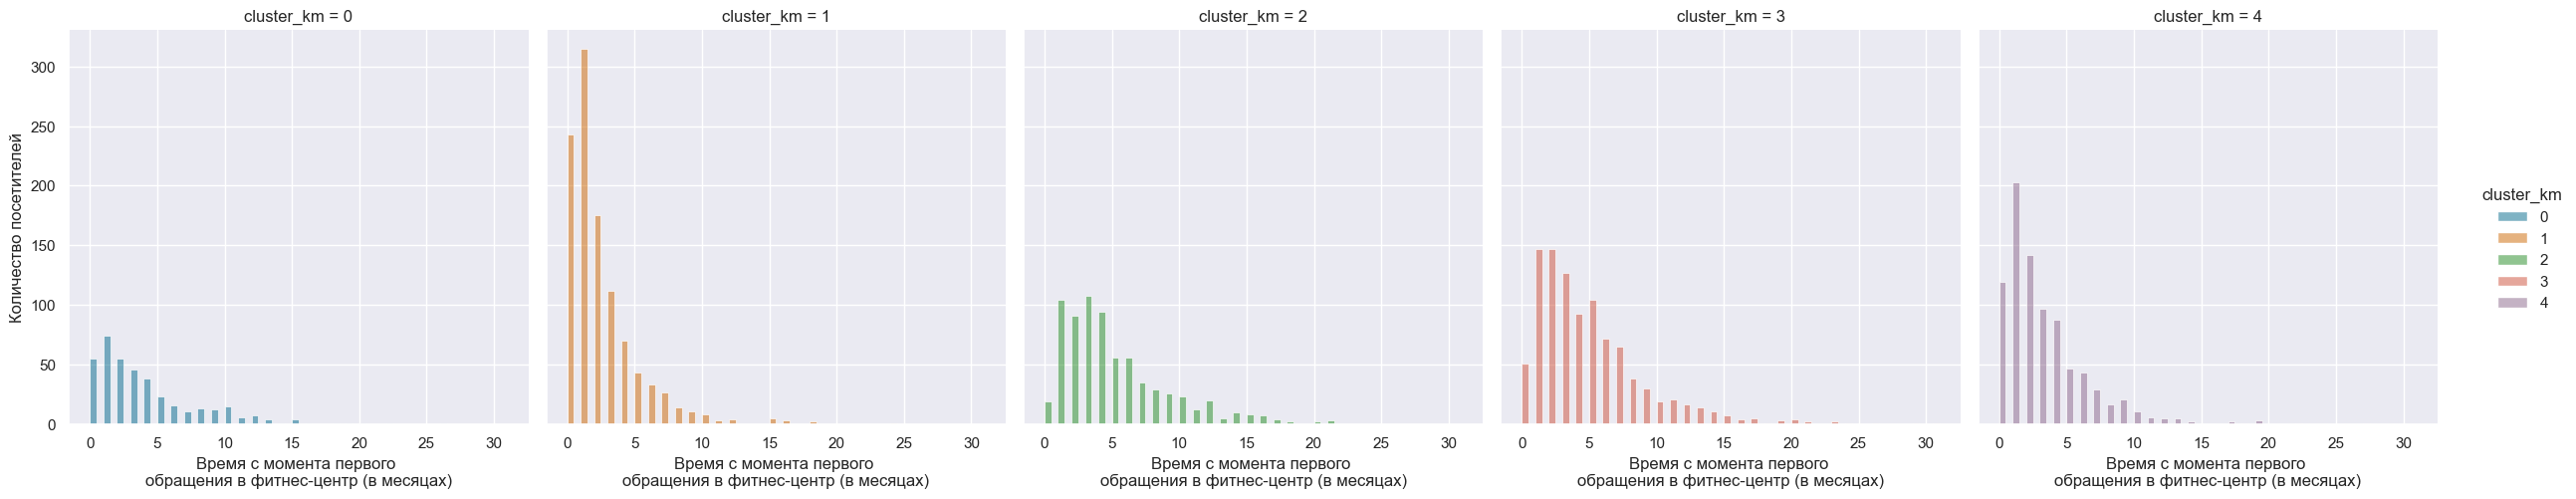

C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


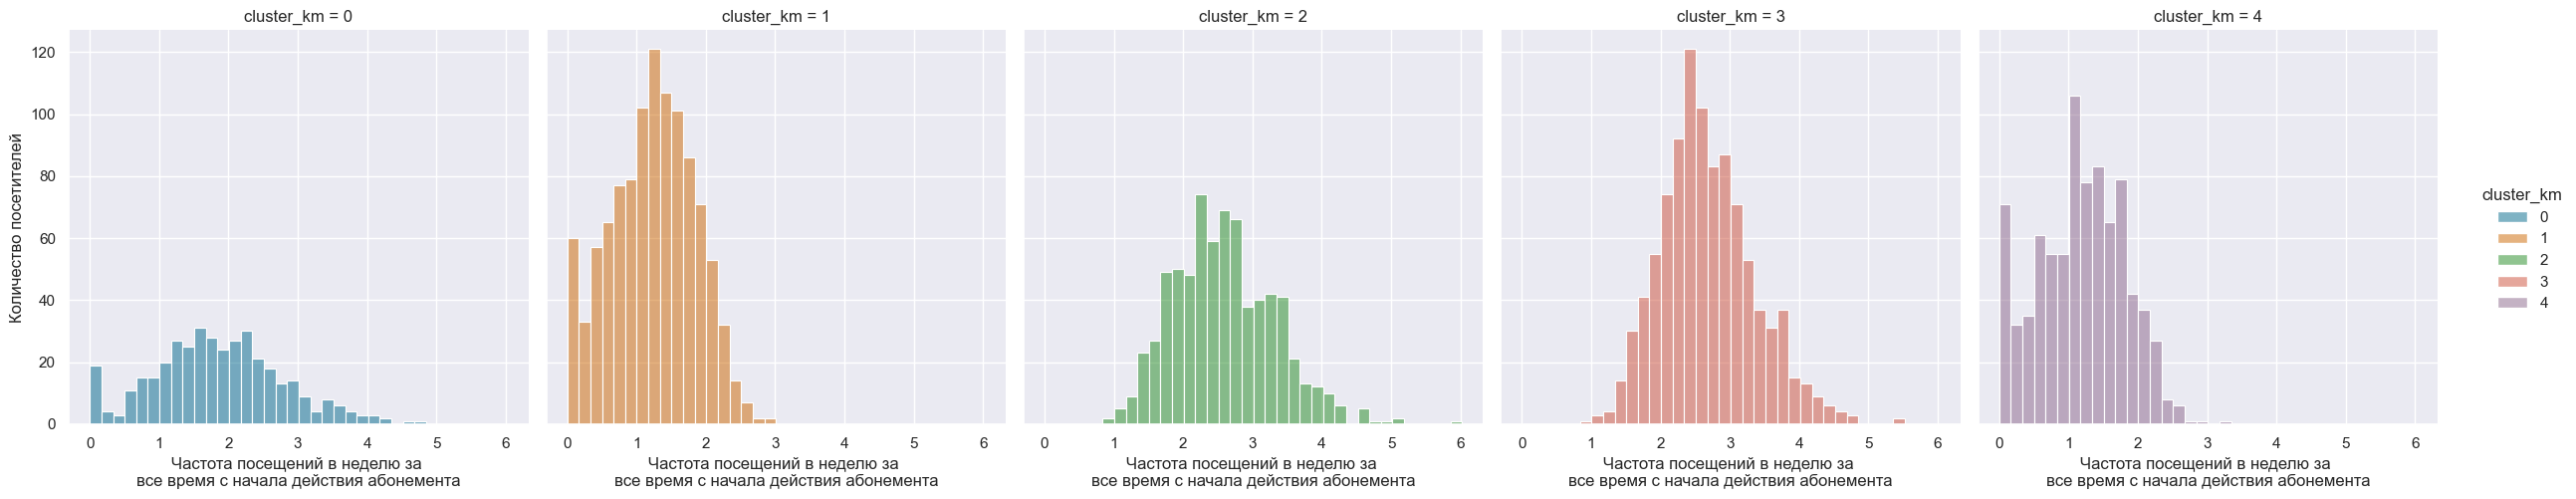

C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\ageev\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


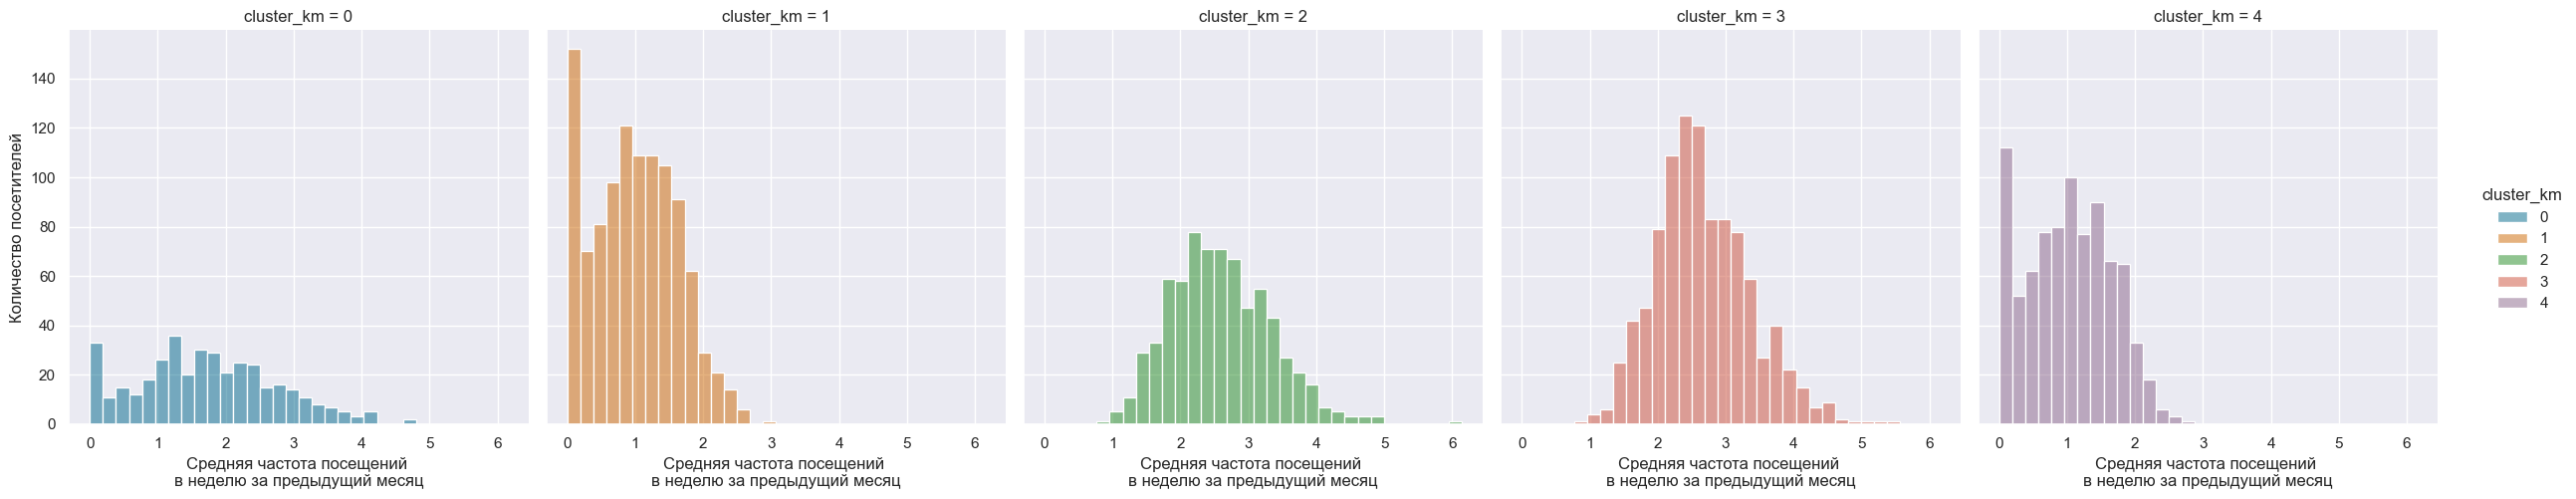

In [21]:
#Выведем циклом гистограммы по всем не булевым характеристикам, каждый кластер выведем на отдельном поле:
for i in df_no_mtec:
    if i in ('churn', 'cluster_km') or i in bool_list:
        continue
    #Каждый кластер на личном графике (двойной клик увеличивает изображение):
    ax = sns.displot(data=df_no_mtec, hue='cluster_km', x=i, col='cluster_km', palette=colors) 
    #Все кластеры на едином поле графика:
    # ax = sns.displot(data=df_no_mtec_no_bool, hue='cluster_km', x=i, palette=colors)
    ax.set(ylabel='Количество посетителей', xlabel=columns_dict.get(i)) 
    plt.show()


<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
 
👍 Вновь замечательно по визуализации. Возможно, нагляднее было бы сделать гистограммы прозрачнее и наложить кластера друг на друга. Так увидим, какой кластер в каком признаке выделяется.

<div class="alert alert-info">
Визуализация в одном поле для всех кластеров закомменчена. Визуализация, которую я предпочел, позволяет четко увидеть динамику внутри каждого кластера в отдельности, к чему я и стремился. Слишком много кластеров на одном графике - сложно разобрать, если пользоваться прозрачностью.
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера #2 <a class="tocSkip"> </h2>

👍 Ок, все зависит от того, что хотим видеть. Если наложим много кластеров, то каждый в отдельности будет смотреться не очень четко, согласен, зато мы сразу же легко увидим, какой из кластеров у нас будет отличаться по распределению от остальных. 
</div>
  

<b> Основные тезисы по кластерам:<br><br>
Кластер 0:</b><br>
901 пользователь. Характеризуется близостью работы или дома к фитнес-центру, ~35% пользователей являются сотрудником компании- партнера, почти никто не участвовал в акции "приведи друга" (1 из 10), остаток действия абонемента в среднем больше 5 месяцев (предполагаю, как правило, берут на длительный период), почти половина пользователей участвует в групповых занятиях, самые высокие траты на доп.услуги, чаще остальных кластеров посещают фитнес-центр (в 1.5 - 2 раза).<br><br>
<b>Кластер 1:</b><br>
1185 - рекордсмен по количеству пользователей. Все пользователи работают или проживают рядом с фитнесс-центром, менее четверти пользователей являются сотрудниками компании-партнера, в акции участвовал только 1 посетитель из 10 , средний период абонемента самый низкий по сравнению с другими кластерами, около трети участвовали в групповых тренировках, самый "молодой" кластер по среднему показателю (если это вообще имеет смысл рассматривать, так как в пределах погрешности), самые низкие траты на доп. услуги, самое низкое посещение в неделю.<br><br>
<b>Кластер 2:</b><br>
534 пользователя. Единственный кластер, состоящий исключительно из пользователей, которые проживают или работают не рядом с фитнес-центром, около половины посетителей - сотрудники компаний-партнеров, реже всех остальных участвовали в акции "приведи друга", средний остаток действия абонемента - менее 3х месяцев, в среднем, посещают зал 1-2 раза в неделю, прочее не принципиально.<br><br>
<b>Кластер 3:</b><br>
995 пользователей. Зал рядом с домом или работой, почти все пользователи являются сотрудниками компаний-партнеров и участвовали в акции "приведи друга", самый высокий средний остаток действия договора, чаще остальных участвуют в групповых занятиях, тратят больше многих на доп. услуги, посещают зал около 2х раз в неделю (полагаю корпоративные клиенты).<br><br>
<b>Кластер 4:</b><br>
385 пользователей - самый немногочисленный кластер. 86% посетителей зала работают или проживают рядом с фитнес-центром, чуть менее половины посетителей являются сотрудниками компаний-партнеров, 30% пользователей "привели друга", данная кагорта единственная, которая полностью состоит из тех, чьи телефоны отсутствуют в базе, остаток периода договора - чуть менее 5 месяцев, средне заинтересованы в участии в групповых занятиях, траты на доп. услуги - средние, до 2х занятий в неделю на посетителя.  

Рассмотрим доли оттока по кластерам.

In [22]:
churc_parts = df_no_mtec[df_no_mtec['churn']==1].groupby('cluster_km')['churn'].agg('count')/df_no_mtec[df_no_mtec['churn']==1]['churn'].agg('count')
display(churc_parts)

cluster_km
0   0.0971
1   0.5495
2   0.0113
3   0.0782
4   0.2639
Name: churn, dtype: float64

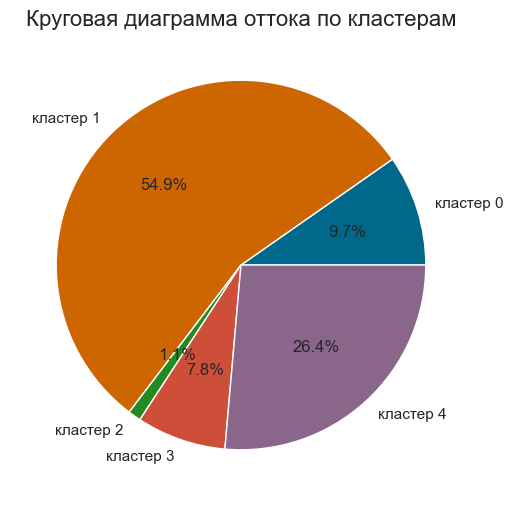

In [23]:
#Заведем список с наименованием кластеров (0,1,2,3,4 выглядят не солидно ):
keys = ['кластер 0','кластер 1', 'кластер 2', 'кластер 3', 'кластер 4'] 
  
# Построим круговую диаграмму по кластерам с долей оттока:
plt.pie(x= churc_parts.values, labels=keys, colors=colors, autopct='%.1f%%') 
plt.title('Круговая диаграмма оттока по кластерам', fontsize=16)
plt.show()

Рассмотрим тепловую карту корреляции по кластерам:

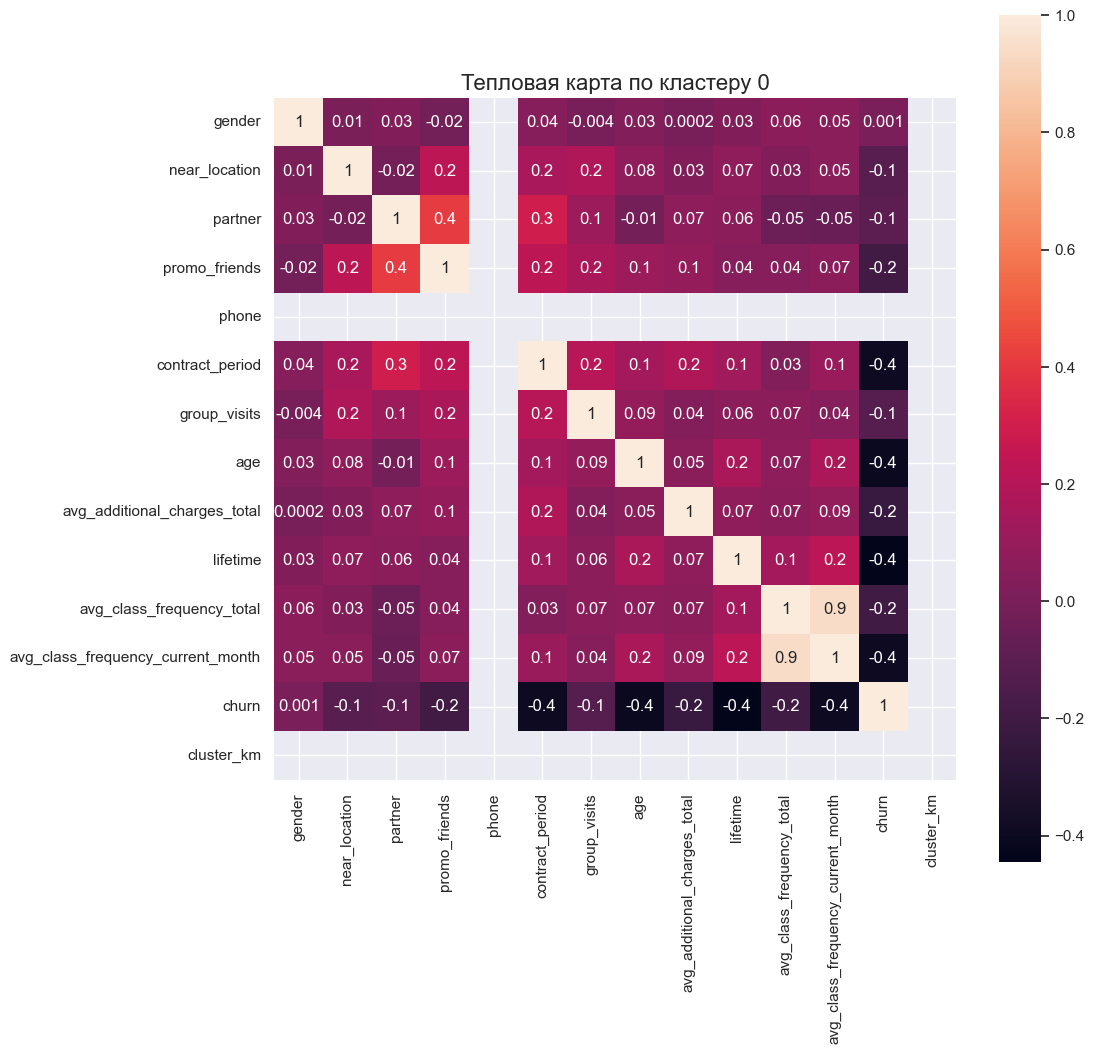

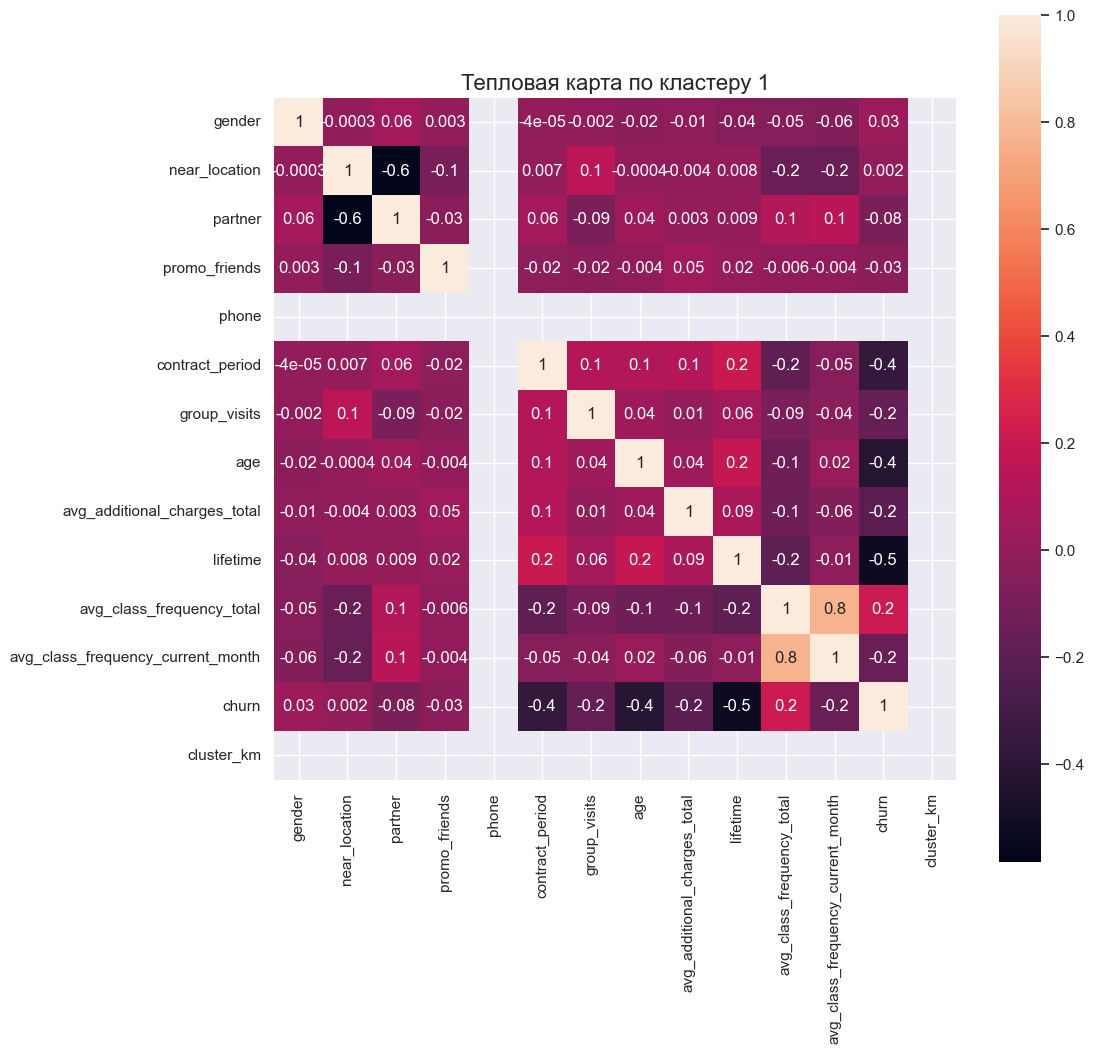

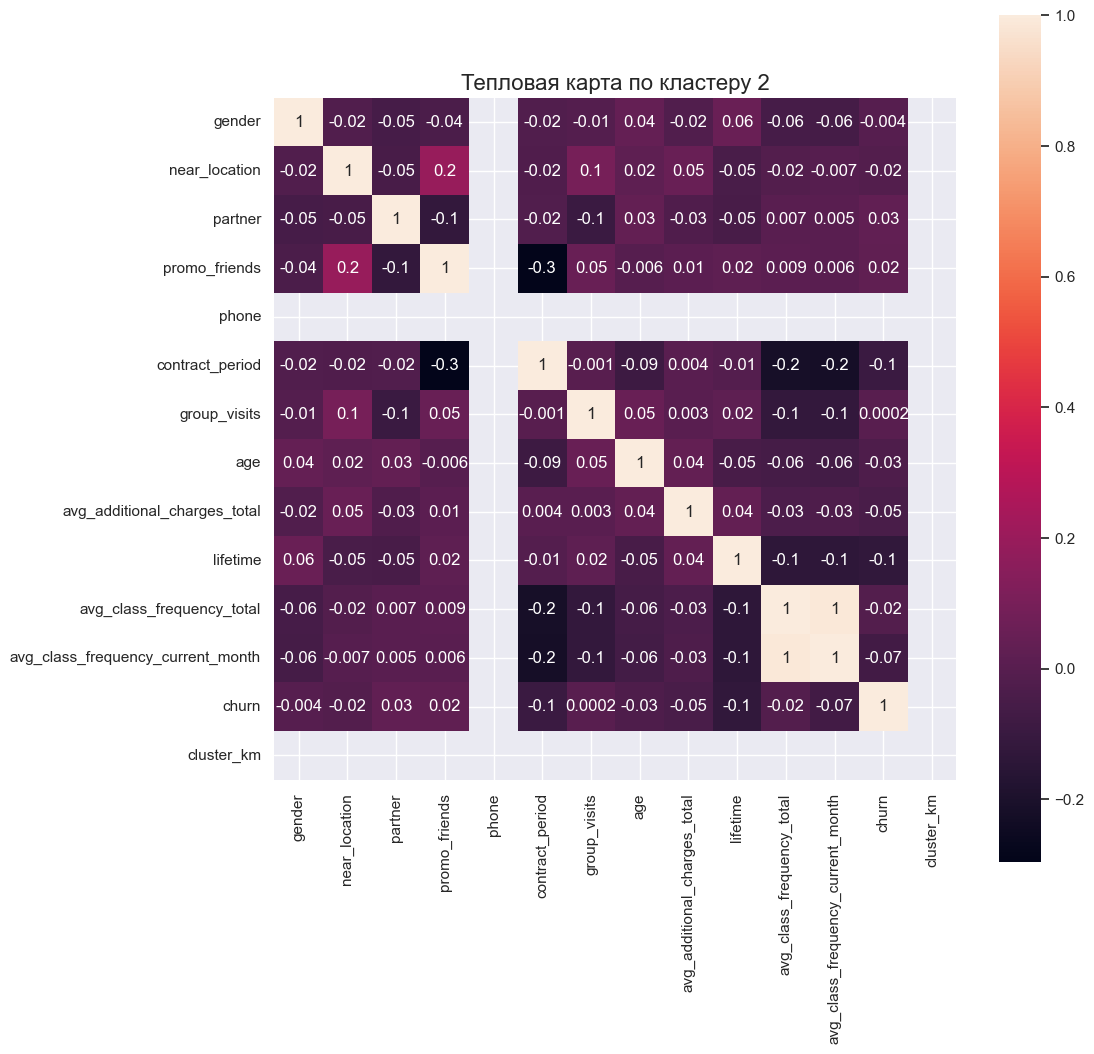

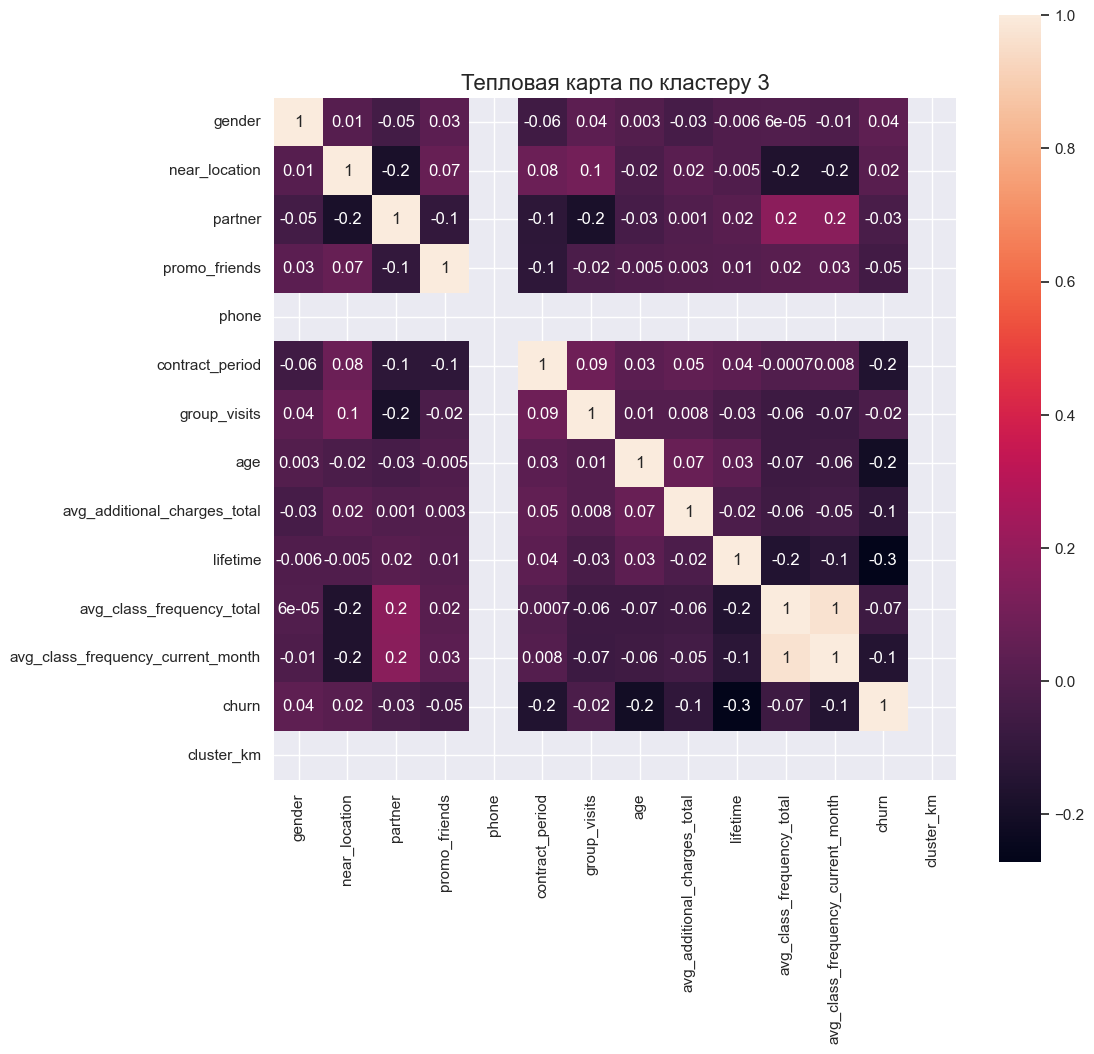

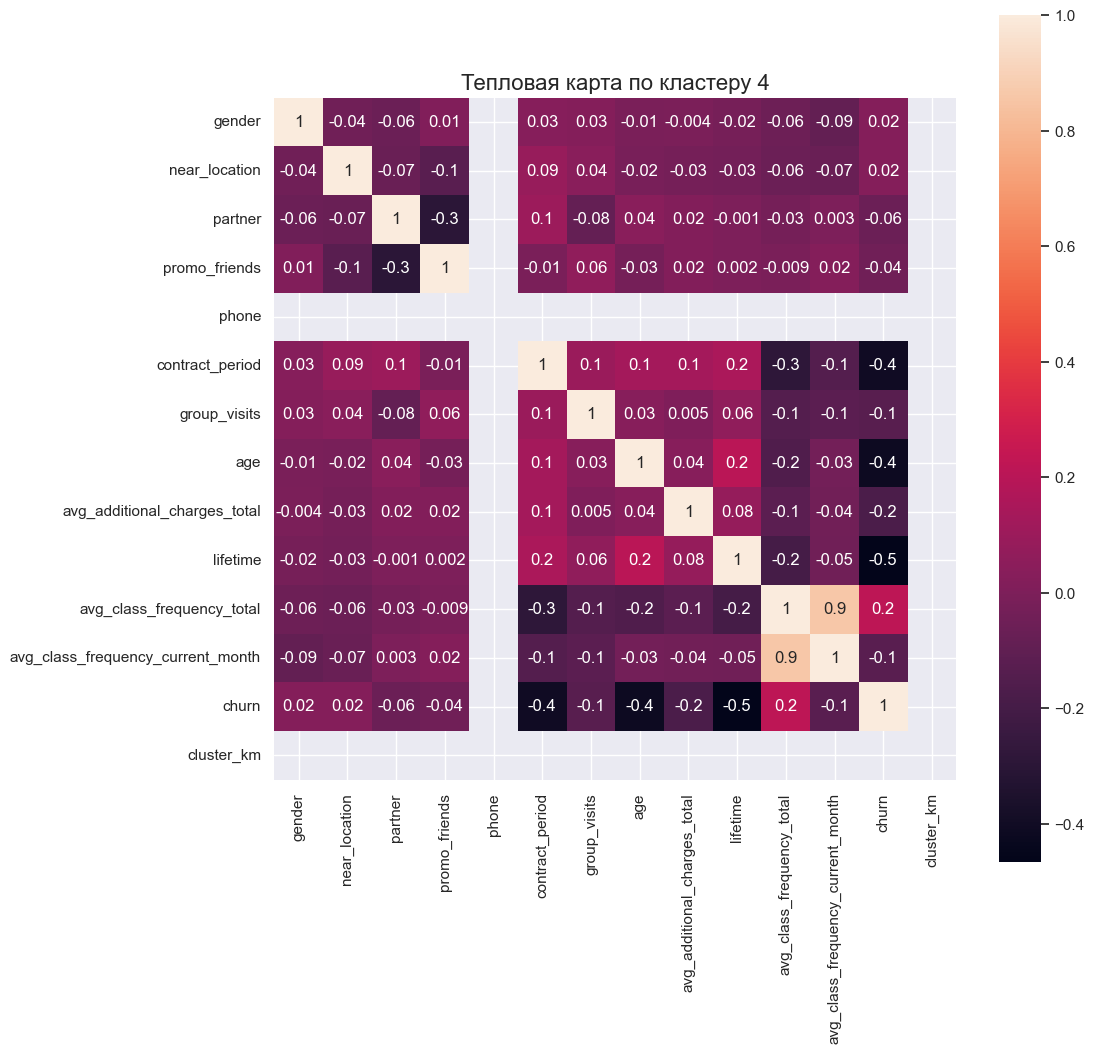

In [24]:
for i in range(5):
    #Каждый кластер на личном графике (двойной клик увеличивает изображение):
    plt.figure(figsize=(11,11))
    ax = sns.heatmap(df_no_mtec[df_no_mtec['cluster_km']==i].corr(), square = True, annot = True, fmt='.1g')
    ax.set_title(f'Тепловая карта по кластеру {i}' , fontsize = 16)

    plt.show()

`Кластер с самым высоким оттоком - 1` (56%), связано это с тем, что большая часть абонементов, которые преобретают  пользователи расчитана на 1 месяц. Также, посетители из указанной кагорты реже остальных, в принципе, посещают фитнес-центр. Не удевлюсь, если период, на который преобретается абонемент совпадает с графиком отключения горячей воды в районе.<br>
`Кластер, который слабее остальных подвержен оттоку - 0 (3.5%)`. <br>
`3 и 4 кластеры` вообще, зря разбиты, по моему мнению. Я бы в 1 кластер объединил, разница только в указанном номере телефона, `слабо подвержены оттоку.`<br>
`2 кластер - средне подвержен оттоку`, пользователям не удобно пользоваться услугами фитнес-центра, ввиду удаленности, но всё-таки посещают, возможно так как посещают зал в то время, когда в секциях занимаются их дети или после переезда / смены работы, остался остаток посещений, который не желательно "выбрасывать".
<br><br>

<b>Выводы и рекомендации: </b><br>
Как говорилось выше: 0 и 1 кластеры являются схожими по показателям, при этом, отток у 0 кластера составляет 3.5%, а у 1 - более 56%. Преимущественная разница лишь в периоде договора между клиентом и фитнес-центром, а также средняя частота посещения фитнес-центров. Полагаю, что у фитнес-центра действует акция на преобретение абонемента на первый месяц и люди соглашаются на покупку по акции, при этом не особо стремясь к посещению. После окончания "пробника" и вовсе возвращаться не стремятся. По себе знаю, что первый месяц - самый сложный в плане начать и не бросить (новая обстановка, никого не знаешь, как заниматься или выполнять упражнения не в курсе).

1. В таких условиях, при приобретении абонемента на месяц, желательно на пробное занятие приставлять грамотное сопровождение в лице инструктора к посетителю, который введет в курс, объяснит, покажет, порекомендует, в крайних случаях предупредит или даже предотвратит необратимое. Это снимет страх, скованность и поможет посетителю "влиться" в дружный коллектив постоянных посетителей.<br>
2. Как говорил ранее, проводить различные челенджи, соревнования, мероприятия (возможно семейные), с небольшими призами или сувенирами, да хотя бы грамотами. Это повысит мотивацию, желание посещать фитнес-центр. Возрастёт посещаемость - снизится вероятность оттока.
3. Организовывать секции для детей, для совместного посещения фитнес-центра (хореография, единоборства). Данное действие позволит привлечь людей с детьми, которые считают, что их наличие является значимым оправданием к игнорированию развития своего здоровья, духа, прочих качеств (в моем личном случае, даже коммуникативных).
4. Помимо акций, стоит следить за состоянием оборудования, чистотой. В т.ч. если посетитель не приносит своё полотенце, предлагать на стойке ресепшн клубное за доп. плату (чистое и свежее). Это поднимет авторитет среди посетителей, т.к. после посетителя не приятно заниматься, если его "следы" остаются на тренажёре. Что в свою очередь повысит посещаемость, следовательно уменьшит отток.

Что касаемо 2 кластера, у которого 21% оттока, то у него основная "фича" - НЕ близость фитнес-центра к дому, работе. Люди заинтересованы посещать по другим причинам. Думаю, тут повлиять вряд ли получится за счёт акций, только перенос или открытие еще одного или нескольких залов, но проект не об этом.

